# Bayesian Analysis of the Gender Gap in Mathematics Achievement
## Evidence from PISA 2022 (Poland) — *Stan implementation*

**Authors:** Krzysztof Witek &nbsp;|&nbsp; Mateusz Sabat — *AIR*

**Course:** Data Analytics — Bayesian Modeling Project

---

This report presents a complete Bayesian workflow applied to a single, well-defined
phenomenon: **the difference in mathematics achievement between boys and girls** in the
2022 cycle of the *Programme for International Student Assessment* (PISA), restricted to
students from **Poland**.


The notebook follows the canonical Bayesian workflow:

1. **Problem formulation** — phenomenon, objectives, data, and preprocessing.
2. **Model specification** — two competing generative models, written in Stan.
3. **Prior analysis** — rationale, and prior predictive checks on both *parameters* and *measurements*.
4. **Model fitting and posterior analysis** — sampling diagnostics, posterior predictive checks,
   and marginal posterior analysis for each model separately.
5. **Model comparison** — out-of-sample predictive accuracy via **WAIC** and **PSIS-LOO**.
6. **Conclusions** — what the data tell us about the gender gap.


## 0. Environment and reproducibility

We rely on **CmdStanPy** to compile and fit the Stan models, **ArviZ** for diagnostics and
visualization, and **pandas / numpy / matplotlib / seaborn** for data handling and plotting.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cmdstanpy
import arviz as az

# Keep CmdStanPy's per-chain INFO logging quiet in the rendered report.
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.setLevel(logging.WARNING)

# Global configuration
RANDOM_SEED = 2022
rng = np.random.default_rng(RANDOM_SEED)

az.style.use("arviz-darkgrid")
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

# Paths are relative to the notebook/ folder.
STAN_DIR = os.path.join("..", "stan")
DATA_CSV = os.path.join("..", "pisa_poland_raw.csv")
SAV_FILE = os.path.join("..", "CY08MSP_STU_QQQ.SAV")


## 1. Problem formulation

### 1.1 Problem statement

International large-scale assessments such as PISA repeatedly report a **gender gap in
mathematics**: in many countries 15-year-old boys, on average, slightly outperform girls on
the mathematics scale. A naive comparison of raw averages, however, conflates *gender* with
everything that happens to be correlated with gender in the sample — family background, the
learning climate students experience, and personal attitudes toward effort.

The question we ask is therefore deliberately **conditional**:

> *Does a student's gender carry additional information about their PISA mathematics score
> once we have already accounted for socio-economic status, the disciplinary climate of
> mathematics lessons, and the student's perseverance?*

In other words, we do not want to know merely *whether* boys outscore girls on average; we
want to know whether a **gender effect survives** after controlling for other plausible
explanations of achievement.

### 1.2 Thesis

> **Boys achieve higher mathematics scores than girls in PISA 2022, even after adjusting for
> differences in socio-economic status (ESCS), disciplinary climate (DISCLIM), and
> perseverance (PERSEVAGR).**

Formally, we expect the gender coefficient \(\gamma\) (effect of being female, relative to
male) in the extended model to be **negative** and for its posterior to be concentrated away
from zero.

### 1.3 Objectives and use cases

The point of building these models is both **inferential** and **predictive**:

* **Inferential / scientific.** Quantify, *with calibrated uncertainty*, the conditional
  gender gap. A Bayesian treatment gives us a full posterior distribution for \(\gamma\)
  rather than a single point estimate and a p-value, which is exactly what is needed to talk
  honestly about effect *size* and *uncertainty*.
* **Educational-policy use case.** If a meaningful conditional gap exists, it points to
  factors *not captured* by socio-economic background or classroom climate — for example,
  differences in confidence, anxiety, or stereotype effects — and motivates targeted
  interventions. If the gap essentially vanishes after controls, the apparent raw gap is
  largely explained by the controlled factors.
* **Methodological use case.** The pair of models is a clean, interpretable demonstration of
  **nested model comparison**: does adding one predictor (gender) genuinely improve
  out-of-sample predictive performance, or does it merely add a parameter?

### 1.4 Data source and description

The data come from the **OECD Programme for International Student Assessment (PISA) 2022**,
the eighth cycle of the study. The student questionnaire data file
(`CY08MSP_STU_QQQ.SAV`) contains **613,744 students** described by **1,278 variables** across
all participating countries/economies.

We restrict the analysis to **Poland (`CNT == "POL"`)**. This is a deliberate design choice:
by analyzing a single country we **avoid having to model between-country differences** (in
curricula, language, sampling design, and cultural context), which would otherwise require a
hierarchical multi-country model and distract from the focused gender-gap question.

The variables we use are summarized below.

| Variable | PISA name | Category | Meaning | Role |
|---|---|---|---|---|
| **y** | `PV1MATH … PV10MATH` | outcome | Mathematics achievement on the PISA scale (≈ mean 500, sd 100 internationally) | dependent variable |
| **ESCS** | `ESCS` | home / family | Index of economic, social and cultural status | control |
| **DISCLIM** | `DISCLIM` | school / lesson | Disciplinary climate in mathematics lessons (WLE) | control |
| **PERSEVAGR** | `PERSEVAGR` | personal trait | Perseverance / agreement (WLE) | control |
| **female** | `ST004D01T` | demographic | 1 = girl, 0 = boy | predictor (Model 2 only) |

**A note on Plausible Values (PVs).** PISA does *not* report a single test score per student.
Because each student answers only a fraction of the full item pool, the student's proficiency
is a *latent* quantity that is only partially observed. PISA therefore draws **10 "plausible
values"** from each student's posterior proficiency distribution. The methodologically clean
way to use them is to run every analysis 10 times and combine via *Rubin's rules*. For this
project — whose focus is the Bayesian workflow rather than PISA's measurement model — we use
the **average of the 10 plausible values** as the outcome `y`. This is a common, transparent
simplification; we note it explicitly as a limitation in the conclusions, since averaging PVs
slightly *understates* the measurement uncertainty in the proficiency estimate.

### 1.5 Preprocessing

The preprocessing pipeline is intentionally simple and fully reproducible:

1. **Column subset & country filter.** From the 1,278 columns we keep only the variables
   listed above and filter to `CNT == "POL"`.
2. **Outcome construction.** `y = mean(PV1MATH … PV10MATH)`, kept on the **original PISA
   point scale** (no transformation), as specified in the project design.
3. **Gender recoding.** `ST004D01T` is recoded to a binary `female` indicator
   (1 = Female, 0 = Male). The few special codes (valid skip / no response) do not occur for
   Poland, so every student is cleanly classified.
4. **Missing data.** Students with missing values on any of the three continuous predictors
   (ESCS, DISCLIM, PERSEVAGR) are dropped (**complete-case analysis**). This is a pragmatic
   choice; the amount of missingness is modest (see below) and a full missing-data model is
   out of scope.
5. **Standardization of continuous predictors.** ESCS, DISCLIM and PERSEVAGR are
   **z-standardized** (mean 0, sd 1) using the formula
   $$x^{\text{std}}_i = \frac{x_i - \bar{x}}{s_x}$$
   Standardization (a) makes the regression coefficients directly comparable as
   *"points per one standard deviation"*, and (b) keeps the predictors on a common scale,
   which makes the priors easier to reason about. The binary `female` predictor and the
   outcome `y` are **left untransformed**.


### 1.6 Loading the data

The cell below loads the data. To keep the notebook fast and portable it first looks for a
cached CSV containing only the Poland subset and the columns we need
(`../pisa_poland_raw.csv`). If that cache is not present, it reads the relevant columns
directly from the original 2 GB SPSS file using `pyreadstat` and writes the cache. Either way
the result is identical.


In [3]:
PV_COLS = [f"PV{i}MATH" for i in range(1, 11)]
KEEP = ["CNT", "CNTRYID", "ST004D01T", "ESCS", "DISCLIM", "PERSEVAGR", "W_FSTUWT"] + PV_COLS

if os.path.exists(DATA_CSV):
    raw = pd.read_csv(DATA_CSV)
    print(f"Loaded cached Poland subset: {raw.shape[0]} rows x {raw.shape[1]} cols")
else:
    import pyreadstat
    print("Cache not found - reading the relevant columns from the SPSS file (this is slow)...")
    full, meta = pyreadstat.read_sav(SAV_FILE, usecols=KEEP)
    raw = full[full["CNT"] == "POL"].copy()
    raw.to_csv(DATA_CSV, index=False)
    print(f"Extracted and cached Poland subset: {raw.shape[0]} rows x {raw.shape[1]} cols")

raw.head()

Loaded cached Poland subset: 6011 rows x 17 cols


,CNT,CNTRYID,ST004D01T,PERSEVAGR,DISCLIM,ESCS,W_FSTUWT,PV1MATH,PV2MATH,PV3MATH,PV4MATH,PV5MATH,PV6MATH,PV7MATH,PV8MATH,PV9MATH,PV10MATH
0,POL,616.0,1.0,-0.1931,-0.6730,-0.3559,51.36784,472.381,470.698,511.061,456.937,498.779,543.402,519.592,485.898,430.115,444.018
1,POL,616.0,2.0,NaN,NaN,-1.4443,57.65147,282.441,336.395,326.903,335.895,296.008,283.905,302.218,292.220,281.686,281.542
2,POL,616.0,2.0,-0.6357,-0.5067,0.8803,52.65251,564.474,614.934,594.868,590.828,628.696,590.490,593.549,553.680,612.946,623.378
3,POL,616.0,2.0,0.7736,-0.1254,1.2820,87.68793,501.103,462.901,553.516,570.697,573.531,530.642,522.960,489.507,498.612,498.648
4,POL,616.0,2.0,0.1663,-0.1273,0.1402,60.62941,507.672,471.016,430.516,504.195,466.635,511.055,521.101,521.675,494.181,535.206


In [4]:
df = raw.copy()

df["y"] = df[PV_COLS].mean(axis=1)

df["female"] = (df["ST004D01T"] == 1.0).astype(int)

miss = df[["ESCS", "DISCLIM", "PERSEVAGR"]].isna().sum()
print("Missing values per predictor (before complete-case filter):")
print(miss.to_string())
print(f"\nStudents before filter: {len(df)}")

df = df.dropna(subset=["ESCS", "DISCLIM", "PERSEVAGR"]).reset_index(drop=True)
print(f"Students after  filter: {len(df)}  "
      f"({100*(1-len(df)/len(raw)):.1f}% removed)")

Missing values per predictor (before complete-case filter):
ESCS         136
DISCLIM      344
PERSEVAGR    421

Students before filter: 6011
Students after  filter: 5414  (9.9% removed)


In [5]:
PRED_RAW = ["ESCS", "DISCLIM", "PERSEVAGR"]
standardization_summary = {}
for c in PRED_RAW:
    mu, sd = df[c].mean(), df[c].std()
    df[c + "_z"] = (df[c] - mu) / sd    #Z-standarization
    standardization_summary[c] = {"mean": mu, "sd": sd}

std_tbl = pd.DataFrame(standardization_summary).T
std_tbl.index.name = "variable"
print("Standardization constants (computed on the analytic sample):")
display(std_tbl.round(4))

df[[c + "_z" for c in PRED_RAW]].describe().round(3)

Standardization constants (computed on the analytic sample):


,mean,sd
variable,,
ESCS,-0.0531,0.8712
DISCLIM,-0.0144,0.9700
PERSEVAGR,-0.2668,0.8926


,ESCS_z,DISCLIM_z,PERSEVAGR_z
count,5414.000,5414.000,5414.000
mean,0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-6.004,-2.555,-6.382
25%,-0.865,-0.552,-0.563
50%,-0.032,-0.066,-0.151
75%,0.885,0.672,0.443
max,4.587,1.923,5.672


### 1.7 Exploratory data analysis

Before modeling we look at the data descriptively. This serves three purposes: it (a)
documents the sample, (b) gives us a first, *model-free* look at the gender gap, and (c)
sanity-checks that the relationships we intend to model (e.g. ESCS → score) are actually
present.


In [5]:
# Descriptive summary of the analytic variables
desc = df[["y", "ESCS", "DISCLIM", "PERSEVAGR", "female"]].describe().T
display(desc.round(3))

n_girls = int(df["female"].sum())
n_boys = int((1 - df["female"]).sum())
print(f"Analytic sample: n = {len(df)}  |  boys = {n_boys}  |  girls = {n_girls}")

,count,mean,std,min,25%,50%,75%,max
y,5414.0,501.881,81.112,261.386,444.953,502.945,559.327,779.500
ESCS,5414.0,-0.053,0.871,-5.284,-0.806,-0.081,0.718,3.943
DISCLIM,5414.0,-0.014,0.970,-2.493,-0.550,-0.079,0.637,1.851
PERSEVAGR,5414.0,-0.267,0.893,-5.964,-0.769,-0.402,0.128,4.796
female,5414.0,0.515,0.500,0.000,0.000,1.000,1.000,1.000


Analytic sample: n = 5414  |  boys = 2625  |  girls = 2789


In [6]:
# Raw (unadjusted) gender gap
g = df.groupby("female")["y"].agg(["mean", "std", "count"])
g.index = ["Boys (0)", "Girls (1)"]
display(g.round(2))

raw_gap = df.loc[df.female == 1, "y"].mean() - df.loc[df.female == 0, "y"].mean()
print(f"Raw unadjusted gap (girls - boys): {raw_gap:.2f} PISA points")
print("Boys score higher on average, consistent with the thesis. "
      "The modeling question is whether this survives controls.")

,mean,std,count
Boys (0),508.55,86.25,2625
Girls (1),495.60,75.43,2789


Raw unadjusted gap (girls - boys): -12.95 PISA points
Boys score higher on average, consistent with the thesis. The modeling question is whether this survives controls.


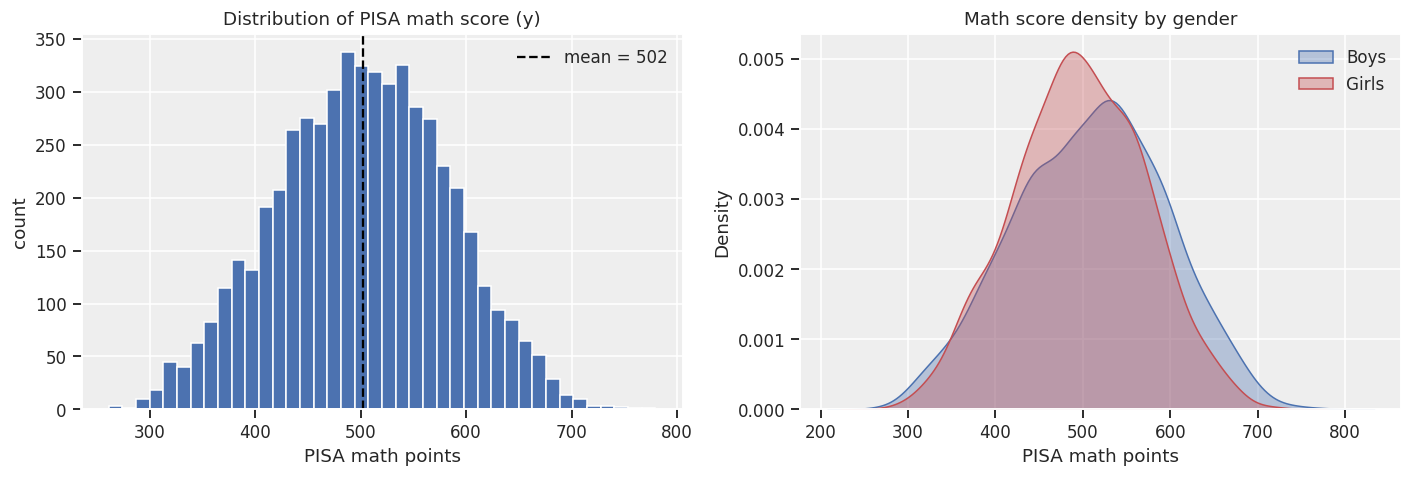

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["y"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["y"].mean(), color="k", ls="--", label=f"mean = {df['y'].mean():.0f}")
axes[0].set_title("Distribution of PISA math score (y)")
axes[0].set_xlabel("PISA math points") 
axes[0].set_ylabel("count") 
axes[0].legend()

for val, lab, col in [(0, "Boys", "#4C72B0"), (1, "Girls", "#C44E52")]:
    sns.kdeplot(df.loc[df.female == val, "y"], ax=axes[1], label=lab, fill=True,
                alpha=0.35, color=col)
axes[1].set_title("Math score density by gender")
axes[1].set_xlabel("PISA math points")
axes[1].legend()
plt.tight_layout(); plt.show()

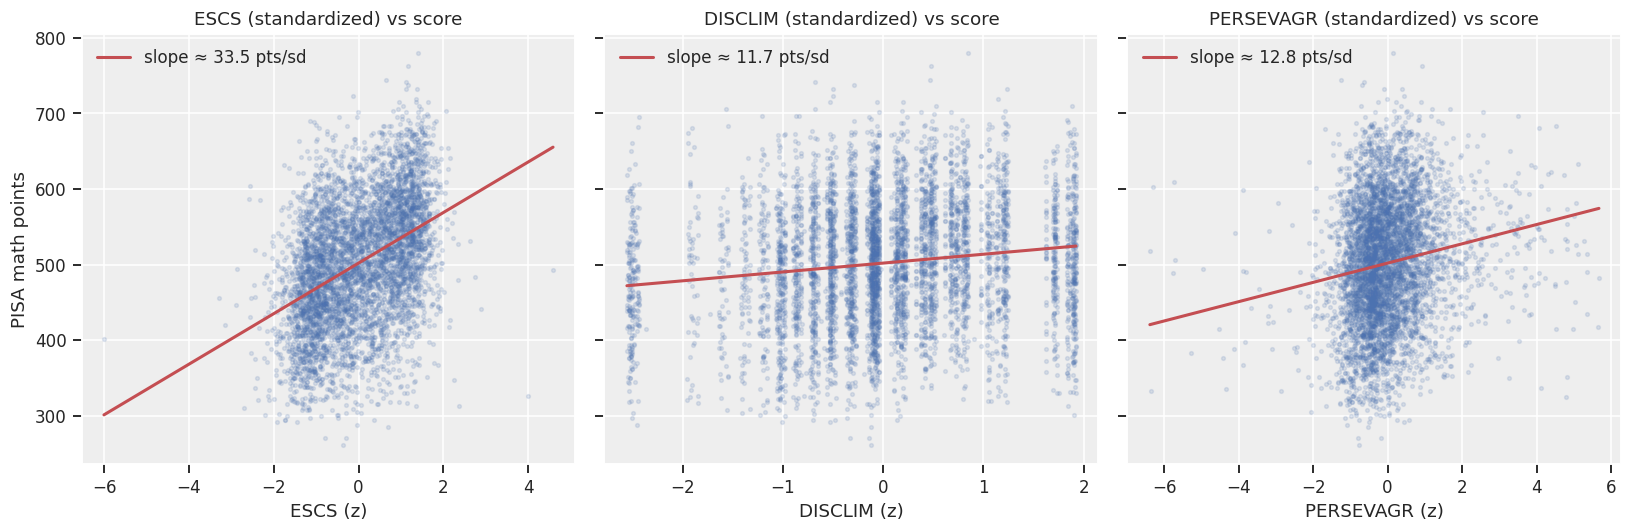

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, c in zip(axes, PRED_RAW):
    ax.scatter(df[c + "_z"], df["y"], s=6, alpha=0.15, color="#4C72B0")
    b1, b0 = np.polyfit(df[c + "_z"], df["y"], 1)
    xs = np.linspace(df[c + "_z"].min(), df[c + "_z"].max(), 50)
    ax.plot(xs, b0 + b1 * xs, color="#C44E52", lw=2,
            label=f"slope ≈ {b1:.1f} pts/sd")
    ax.set_title(f"{c} (standardized) vs score")
    ax.set_xlabel(f"{c} (z)"); ax.legend(loc="upper left")
axes[0].set_ylabel("PISA math points")
plt.tight_layout(); plt.show()

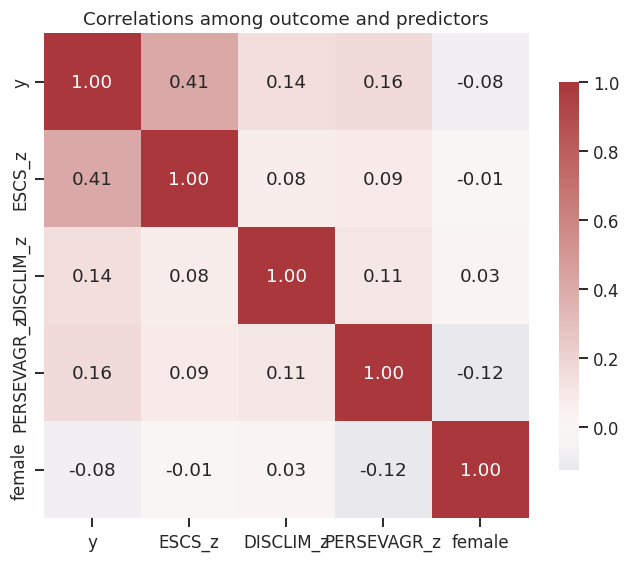

In [ ]:
corr = df[["y", "ESCS_z", "DISCLIM_z", "PERSEVAGR_z", "female"]].corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlations among outcome and predictors")
plt.show()

**What the EDA tells us.**

* The outcome is roughly **bell-shaped** and centered near the international mean of 500,
  which is reassuring for a **Normal** likelihood.
* The **raw gender gap favors boys** by roughly a dozen PISA points — exactly the pattern the
  thesis is about.
* **ESCS** has by far the strongest association with achievement (the steepest slope and the
  largest correlation), followed by weaker positive associations for DISCLIM and PERSEVAGR.
* The predictors are **only weakly correlated with each other**, so each one contributes
  largely non-redundant information — this is precisely why these three controls were chosen
  from three different categories (home, school, personal trait).
* Importantly, `female` is **essentially uncorrelated with ESCS and DISCLIM** but shows a
  small *negative* correlation with perseverance, which previews why controlling for
  PERSEVAGR matters when isolating the gender effect.


## 2. The two models (written in Stan)

We compare **two nested Gaussian linear regression models**. Both treat the (averaged)
mathematics score $y_i$ as Normally distributed around a linear predictor $\mu_i$ with a
common residual standard deviation $\sigma$. They differ by **exactly one predictor** — the
gender indicator — which is what makes the comparison clean and interpretable.

Both models are implemented in the **Stan** language and stored as standalone files in the
`stan/` directory:

* `stan/model1_baseline.stan` — the baseline model (no gender),
* `stan/model2_gender.stan` — the extended model (with gender).

### 2.1 Model 1 — baseline (no gender)

$$
\begin{aligned}
y_i &\sim \mathrm{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha + \beta_1\,\text{ESCS}_i + \beta_2\,\text{DISCLIM}_i + \beta_3\,\text{PERSEVAGR}_i
\end{aligned}
$$

The baseline model explains a student's expected mathematics score from three controls drawn
from three different domains: **family background** (ESCS), **classroom conditions**
(DISCLIM), and **personal disposition** (PERSEVAGR). It deliberately contains **no gender
term** — it represents the hypothesis that, once these factors are known, gender adds nothing.

### 2.2 Model 2 — extended (with gender)

$$
\begin{aligned}
y_i &\sim \mathrm{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha + \beta_1\,\text{ESCS}_i + \beta_2\,\text{DISCLIM}_i + \beta_3\,\text{PERSEVAGR}_i
      + \gamma\,\text{female}_i
\end{aligned}
$$

with $\text{female}_i = 1$ for girls and \(0\) for boys. Model 2 **nests** Model 1: setting
$\gamma = 0$ recovers the baseline exactly.

### 2.3 What is different, and why the difference is justified

| Aspect | Model 1 (baseline) | Model 2 (extended) |
|---|---|---|
| Predictors | ESCS, DISCLIM, PERSEVAGR | ESCS, DISCLIM, PERSEVAGR, **female** |
| Free parameters | $\alpha$, $\beta_1$, $\beta_2$, $\beta_3$, $\sigma$ (5) | $\alpha$, $\beta_1$, $\beta_2$, $\beta_3$, $\gamma$, $\sigma$ (6) |
| Interpretation of $\alpha$ | mean score at average covariates | mean score for **boys** at average covariates |
| Research question | "How well do background factors alone explain math scores?" | "Does gender add information **on top of** those factors?" |

**Why adding the gender parameter makes sense (justification).** The extra parameter
$\gamma$ is not added arbitrarily — it operationalizes the central research question. It has
a precise, policy-relevant meaning: *the expected score difference between a girl and a boy who
have the same socio-economic status, the same disciplinary climate, and the same
perseverance.* This is a **conditional (adjusted) gender gap**, fundamentally different from
the raw gap, because the controls might otherwise absorb or mask the gender signal.
Comparing the two models is therefore a direct test of the thesis: if $\gamma$ is reliably
non-zero **and** Model 2 predicts better out of sample, gender carries genuine additional
information.

A single binary predictor is also the **most parsimonious** way to extend the model — it adds
one degree of freedom — so any improvement in predictive accuracy is unlikely to be a mere
artifact of over-parameterization. This is exactly the kind of difference WAIC and LOO are
designed to adjudicate (Section 6).

### 2.4 Technical description: parameters and required data

| Parameter | Meaning | Units |
|---|---|---|
| \(\alpha\) | expected score at *average* predictor values (for boys, in Model 2) | PISA points |
| \(\beta_1\) | effect of a **+1 sd** change in ESCS | points / sd |
| \(\beta_2\) | effect of a **+1 sd** change in DISCLIM | points / sd |
| \(\beta_3\) | effect of a **+1 sd** change in PERSEVAGR | points / sd |
| \(\gamma\) | adjusted girl-minus-boy difference (Model 2 only) | PISA points |
| \(\sigma\) | residual sd of scores around \(\mu_i\) | PISA points |

**Required data.** For every student we need: the outcome `y` (averaged math PV), the three
standardized predictors, and (for Model 2) the binary `female` indicator. All of these are
assembled in Section 1 and passed to Stan through its `data` block.


### 2.5 The Stan source code

For transparency we print the two Stan programs directly from the `stan/` folder. Note in
each the four blocks: `data` (inputs), `parameters` (unknowns to infer), `model` (priors +
likelihood), and `generated quantities` (pointwise `log_lik` for WAIC/LOO and posterior
predictive replicates `y_rep`).


In [10]:
def show_stan(fname):
    path = os.path.join(STAN_DIR, fname)
    with open(path) as f:
        print(f.read())

print("=" * 70)
print(" stan/model1_baseline.stan ")
print("=" * 70)
show_stan("model1_baseline.stan")

 stan/model1_baseline.stan 
// =====================================================================
// Model 1 - BASELINE (no gender predictor)
//
//   y_i ~ Normal(mu_i, sigma)
//   mu_i = alpha + b_ESCS*ESCS_i + b_DISCLIM*DISCLIM_i + b_PERSEVAGR*PERSEVAGR_i
//
// Priors (weakly-informative, on the PISA point scale):
//   alpha               ~ Normal(500, 50)
//   b_ESCS, b_DISCLIM,
//   b_PERSEVAGR         ~ Normal(0, 30)
//   sigma               ~ Exponential(0.01)
//
// The generated quantities block produces:
//   * log_lik : pointwise log-likelihood, required for WAIC / PSIS-LOO
//   * y_rep   : posterior predictive replicates, for posterior predictive checks
// =====================================================================
data {
  int<lower=0> N;                 // number of students
  vector[N] y;                    // PISA mathematics score (point scale)
  vector[N] ESCS;                 // standardized socio-economic status
  vector[N] DISCLIM;              // standa

In [11]:
print("=" * 70)
print(" stan/model2_gender.stan ")
print("=" * 70)
show_stan("model2_gender.stan")

 stan/model2_gender.stan 
// =====================================================================
// Model 2 - EXTENDED (baseline + gender predictor)
//
//   y_i ~ Normal(mu_i, sigma)
//   mu_i = alpha + b_ESCS*ESCS_i + b_DISCLIM*DISCLIM_i
//                + b_PERSEVAGR*PERSEVAGR_i + gamma*female_i
//
// female_i = 1 for girls, 0 for boys.
// gamma is the ADJUSTED gender gap: expected score difference between a
// girl and a boy with identical ESCS, DISCLIM and PERSEVAGR.
//
// Priors (weakly-informative, on the PISA point scale):
//   alpha               ~ Normal(500, 50)
//   b_ESCS, b_DISCLIM,
//   b_PERSEVAGR, gamma  ~ Normal(0, 30)
//   sigma               ~ Exponential(0.01)
// =====================================================================
data {
  int<lower=0> N;                 // number of students
  vector[N] y;                    // PISA mathematics score (point scale)
  vector[N] ESCS;                 // standardized socio-economic status
  vector[N] DISCLIM;      

In [12]:
# Pull the modeling arrays out once, so both models use identical data.
y_obs     = df["y"].to_numpy()
escs      = df["ESCS_z"].to_numpy()
disclim   = df["DISCLIM_z"].to_numpy()
persev    = df["PERSEVAGR_z"].to_numpy()
female    = df["female"].to_numpy().astype(float)
N         = len(df)

# Stan data dictionaries
stan_data1 = {"N": N, "y": y_obs, "ESCS": escs, "DISCLIM": disclim, "PERSEVAGR": persev}
stan_data2 = {**stan_data1, "female": female}

print(f"N = {N} students")
print(f"y     : mean={y_obs.mean():.1f}, sd={y_obs.std():.1f}, "
      f"range=[{y_obs.min():.0f}, {y_obs.max():.0f}]")
print(f"female: {int(female.sum())} girls / {int((1-female).sum())} boys")

N = 5414 students
y     : mean=501.9, sd=81.1, range=[261, 780]
female: 2789 girls / 2625 boys


In [13]:
# Compile the Stan models with CmdStanPy (uses a cached executable if present).
model1 = cmdstanpy.CmdStanModel(stan_file=os.path.join(STAN_DIR, "model1_baseline.stan"))
model2 = cmdstanpy.CmdStanModel(stan_file=os.path.join(STAN_DIR, "model2_gender.stan"))
print("Model 1 compiled:", os.path.basename(model1.exe_file))
print("Model 2 compiled:", os.path.basename(model2.exe_file))

Model 1 compiled: model1_baseline
Model 2 compiled: model2_gender


## 3. Priors and prior predictive checks

### 3.1 Chosen priors and their rationale

$$
\begin{aligned}
\alpha &\sim \mathrm{Normal}(500,\ 50) \\
\beta_1, \beta_2, \beta_3 &\sim \mathrm{Normal}(0,\ 30) \\
\gamma &\sim \mathrm{Normal}(0,\ 30) \\
\sigma &\sim \mathrm{Exponential}(0.01)
\end{aligned}
$$

These are exactly the priors written in the `model` block of the Stan files. They are
**weakly-informative**: informative enough to keep the model on the PISA scale and rule out
absurd values, but wide enough that the **data dominate** the posterior.

* The PISA scale is constructed so that the OECD
  mean is ~500 with sd ~100. Centering the intercept at 500 encodes this scale knowledge; an
  sd of 50 comfortably covers any plausible national average (a 95% prior interval of roughly
  400–600 PISA points), so the prior is not fighting the data but also not entertaining
  impossible averages like 100 or 900.

* Centering at 0 encodes
  **no assumed direction** for any effect — we let the data decide the sign. Because the
  predictors are standardized, each \(\beta\) is "points per standard deviation". An sd of 30
  says: *a one-sd change in a predictor shifting the score by ±30–60 points is plausible, but
  swings of 100+ points per sd are unlikely.* Given that the entire population sd of scores is
  ~90 points, that is a sensibly **moderate** prior.

* Deliberately **neutral and symmetric** about
  zero — we do *not* bake the thesis into the prior. The data, not the prior, must provide the
  evidence for a gender effect. The sd of 30 admits a substantial gap (tens of points) but
  treats very large gaps as improbable.

* The exponential guarantees positivity. Its
  mean is \(1/0.01 = 100\) PISA points, matching the scale's design sd, so it places
  reasonable prior mass on the residual spread we expect while still allowing smaller or
  larger values.

### 3.2 How the prior parameters were selected (selection method)

The numbers above were **not** tuned to the observed data (that would be "double-dipping").
They were chosen by a **scale-matching** argument grounded in *prior knowledge about the PISA
measurement instrument*:

1. Start from the published construction of the PISA scale (mean ≈ 500, sd ≈ 100).
2. Center location priors on the known scale center (\(\alpha\) at 500; effects at 0 because
   direction is unknown a priori).
3. Set prior spreads to be a fraction of the scale's sd — generous enough to be
   *weakly*-informative (so the likelihood dominates) but tight enough to exclude values that
   are impossible on the PISA scale.
4. **Validate** the whole prior by simulation — the *prior predictive checks* below. If the
   simulated parameters or the simulated data looked unreasonable, we would revise the priors;
   as we will see, they pass.

This is exactly the recommended workflow: choose priors from domain knowledge about the
*scale*, then check them by forward simulation, **before** ever touching the likelihood.


### 3.3 Prior predictive check #1 — do the simulated *parameters* make sense?

First we simply **draw from the priors themselves** and inspect the implied parameter values.
This checks that each prior, on its own, lives on a sensible range. (These are the exact prior
distributions declared in the Stan `model` block; we sample them directly here.)


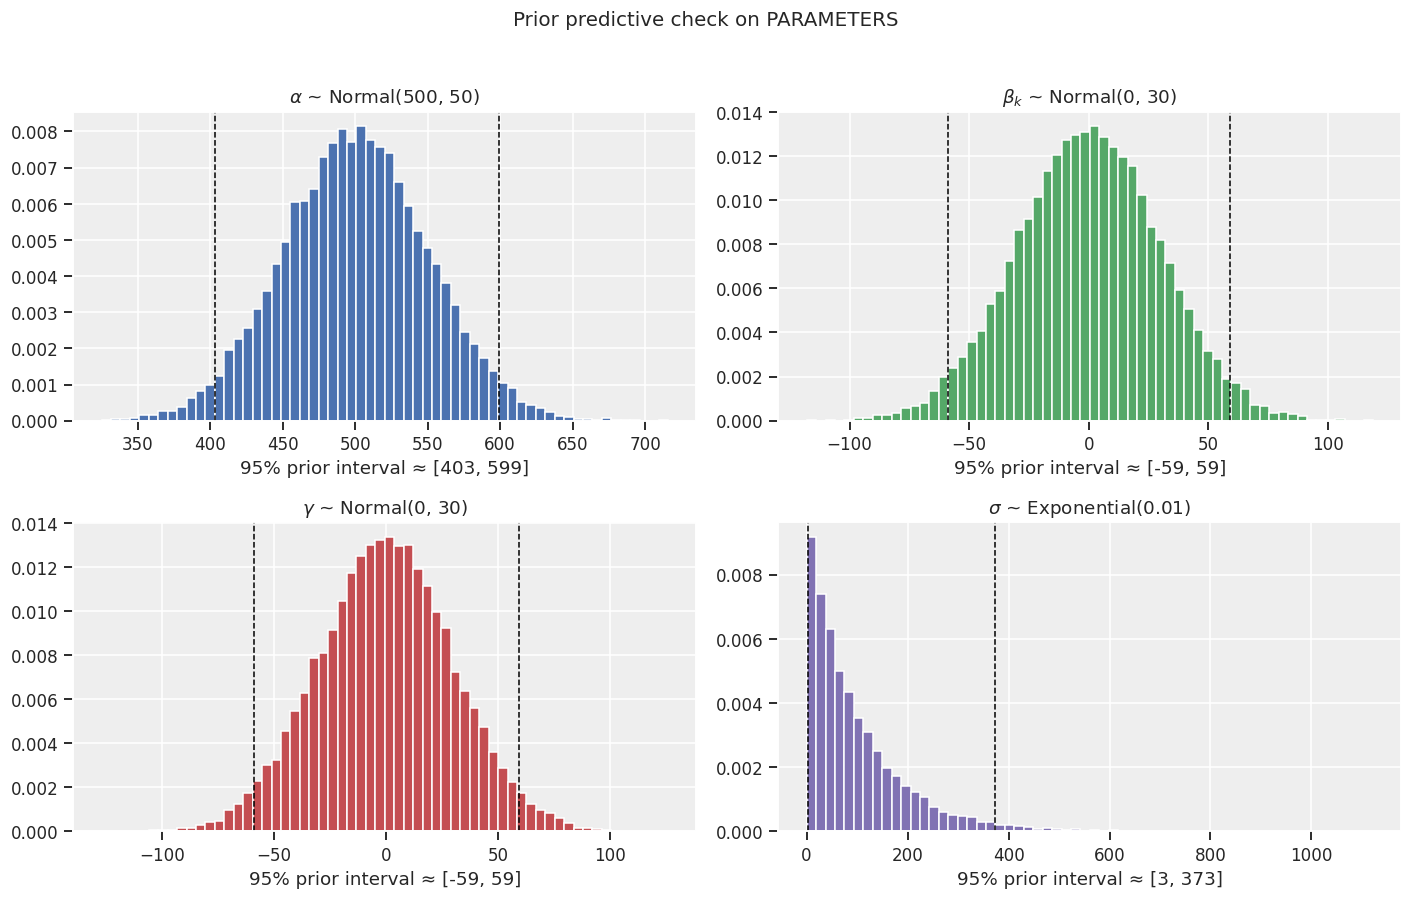

In [14]:
# Draw directly from the prior distributions (closed form)
M = 20000
prior_alpha = rng.normal(500, 50, M)
prior_beta  = rng.normal(0, 30, M)      # representative single beta
prior_gamma = rng.normal(0, 30, M)
prior_sigma = rng.exponential(1 / 0.01, M)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
specs = [
    (prior_alpha, r"$\alpha$ ~ Normal(500, 50)", "#4C72B0", axes[0, 0]),
    (prior_beta,  r"$\beta_k$ ~ Normal(0, 30)",  "#55A868", axes[0, 1]),
    (prior_gamma, r"$\gamma$ ~ Normal(0, 30)",   "#C44E52", axes[1, 0]),
    (prior_sigma, r"$\sigma$ ~ Exponential(0.01)", "#8172B3", axes[1, 1]),
]
for samp, title, col, ax in specs:
    ax.hist(samp, bins=60, color=col, edgecolor="white", density=True)
    ax.set_title(title)
    lo, hi = np.percentile(samp, [2.5, 97.5])
    ax.axvline(lo, color="k", ls="--", lw=1)
    ax.axvline(hi, color="k", ls="--", lw=1)
    ax.set_xlabel(f"95% prior interval ≈ [{lo:.0f}, {hi:.0f}]")
plt.suptitle("Prior predictive check on PARAMETERS", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

**Reading the parameter prior check.**

* \(\alpha\) sits squarely on the PISA scale (95% prior interval ≈ 400–600) — no impossible
  national averages.
* The effect priors (\(\beta_k, \gamma\)) are symmetric about zero, so we are not pre-judging
  any direction, and their ±60-point 95% range is wide but not absurd for a one-sd / boy-girl
  shift.
* \(\sigma\) is strictly positive with most mass between ~5 and ~370 points and a mean near
  100, which brackets the residual spread we plausibly expect.

All four priors are individually reasonable. Next we check what they jointly imply for the
**observable data**, using a dedicated Stan program.


### 3.4 Prior predictive check #2 — do the simulated *measurements* make sense?

This is the more important check. We use a **separate Stan program**,
`stan/prior_predictive.stan`, which has **no likelihood**: it draws parameters from the priors
and pushes them through the generative model to simulate PISA scores `y_sim`. We run it with
Stan's `fixed_param` sampler. We then ask whether the *simulated scores* look like something
that could plausibly come from a real population — *before* we condition on the actual
outcomes.


In [15]:
print("=" * 70)
print(" stan/prior_predictive.stan ")
print("=" * 70)
show_stan("prior_predictive.stan")

 stan/prior_predictive.stan 
// =====================================================================
// PRIOR PREDICTIVE model (baseline structure, no gender term)
//
// This program contains NO likelihood. It draws parameters from their
// priors and pushes them through the generative model to simulate
// measurements y_sim. It is meant to be run with the "fixed_param"
// sampler (algorithm=fixed_param), which simply evaluates the
// generated quantities block once per iteration.
//
// Used in the notebook for the prior predictive check on MEASUREMENTS:
// do data simulated purely from the priors look like plausible PISA
// scores, BEFORE we condition on the observed outcomes?
// =====================================================================
data {
  int<lower=0> N;                 // number of students
  vector[N] ESCS;                 // standardized socio-economic status
  vector[N] DISCLIM;              // standardized disciplinary climate
  vector[N] PERSEVAGR;           

In [16]:
# Compile and run the prior-predictive Stan model with the fixed_param sampler.
prior_model = cmdstanpy.CmdStanModel(
    stan_file=os.path.join(STAN_DIR, "prior_predictive.stan"))

prior_data = {"N": N, "ESCS": escs, "DISCLIM": disclim, "PERSEVAGR": persev}
prior_fit = prior_model.sample(
    data=prior_data, chains=1, iter_sampling=500,
    fixed_param=True, seed=RANDOM_SEED, show_progress=False,
)

# y_sim has shape (draws, N): one simulated dataset per draw.
y_prior = prior_fit.stan_variable("y_sim")
print("Simulated prior-predictive datasets:", y_prior.shape[0],
      "each with", y_prior.shape[1], "students")

17:40:44 - cmdstanpy - INFO - CmdStan start processing


17:40:44 - cmdstanpy - INFO - Chain [1] start processing


17:40:46 - cmdstanpy - INFO - Chain [1] done processing


Simulated prior-predictive datasets: 500 each with 5414 students


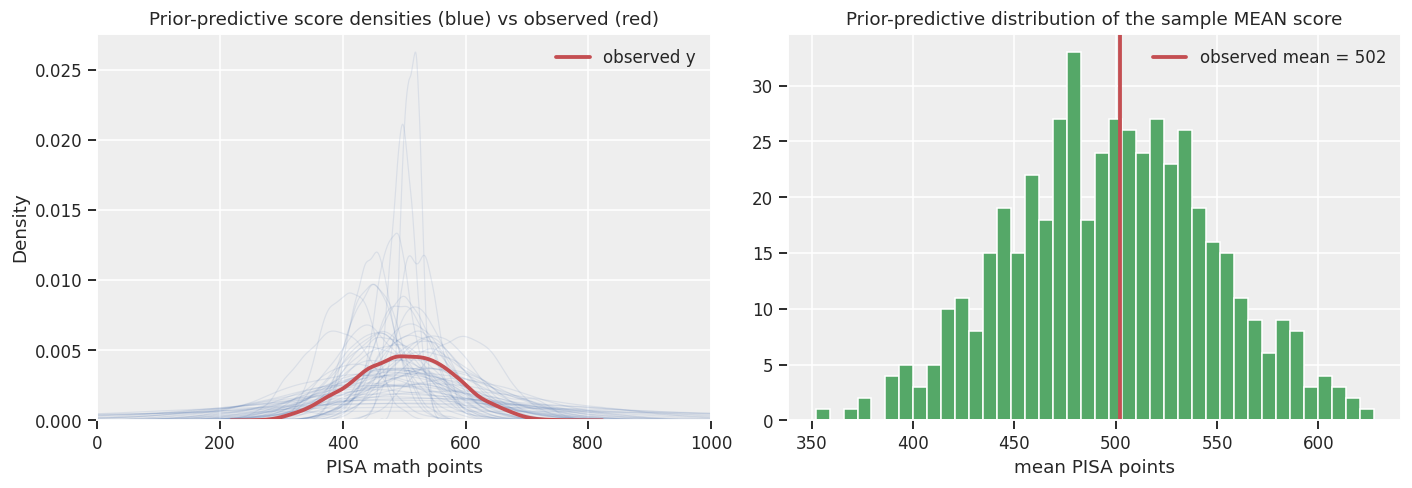

Prior-predictive sample means: 95% range [400, 594]
Share of simulated scores < 0    : 0.9%
Share of simulated scores > 1000 : 0.8%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) A handful of simulated score distributions vs the real one
for i in range(60):
    sns.kdeplot(y_prior[i], ax=axes[0], color="#4C72B0", alpha=0.12, lw=0.8)
sns.kdeplot(y_obs, ax=axes[0], color="#C44E52", lw=2.5, label="observed y")
axes[0].set_title("Prior-predictive score densities (blue) vs observed (red)")
axes[0].set_xlabel("PISA math points"); axes[0].legend()
axes[0].set_xlim(0, 1000)

# (b) Distribution of the simulated dataset MEANS
sim_means = y_prior.mean(axis=1)
axes[1].hist(sim_means, bins=40, color="#55A868", edgecolor="white")
axes[1].axvline(y_obs.mean(), color="#C44E52", lw=2.5,
                label=f"observed mean = {y_obs.mean():.0f}")
axes[1].set_title("Prior-predictive distribution of the sample MEAN score")
axes[1].set_xlabel("mean PISA points"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Prior-predictive sample means: 95% range "
      f"[{np.percentile(sim_means,2.5):.0f}, {np.percentile(sim_means,97.5):.0f}]")
neg = (y_prior < 0).mean() * 100
over = (y_prior > 1000).mean() * 100
print(f"Share of simulated scores < 0    : {neg:.1f}%")
print(f"Share of simulated scores > 1000 : {over:.1f}%")

**Reading the measurement prior check.**

* The simulated score distributions (blue) **comfortably envelop** the observed distribution
  (red): the prior is able to generate data like ours, but is not narrowly tuned to it.
* The prior-predictive **sample means** are centered near 500 and span a wide but realistic
  band, so the prior does not insist on any particular national average.
* A **small fraction** of simulated individual scores fall below 0 or above 1000. This is the
  expected mild side-effect of an unbounded Normal likelihood combined with a large \(\sigma\)
  prior. It is harmless for our purposes: the priors are *weakly*-informative by design, the
  out-of-range mass is small, and once the data enter, the posterior for \(\sigma\) will
  concentrate around its true (much smaller) value. We judge the priors **adequate** and
  proceed without modification.

The priors pass both checks, so we move on to fitting.


## 4. Fitting and posterior analysis — Model 1 (baseline)

We now fit the baseline Stan model with Stan's adaptive HMC / NUTS sampler. We run
**4 chains** so that convergence diagnostics (\(\hat{R}\), ESS) are meaningful. The Stan
`generated quantities` block already returns `log_lik` (for WAIC/LOO) and `y_rep` (posterior
predictive replicates), which we hand to ArviZ.


In [ ]:
def fit_to_idata(fit, observed, has_gender):
    return az.from_cmdstanpy(
        posterior=fit,
        posterior_predictive="y_rep",
        log_likelihood="log_lik",
        observed_data={"y": observed},
        coords={"obs": np.arange(len(observed))},
        dims={"y_rep": ["obs"], "log_lik": ["obs"], "mu": ["obs"]},
    )

fit1 = model1.sample(
    data=stan_data1, chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=2000,
    adapt_delta=0.9, seed=RANDOM_SEED, show_progress=False,
)
idata1 = fit_to_idata(fit1, y_obs, has_gender=False)
print("Model 1 sampling complete.")
print("InferenceData groups:", list(idata1.groups()))

17:40:53 - cmdstanpy - INFO - CmdStan start processing


17:40:53 - cmdstanpy - INFO - Chain [1] start processing


17:40:53 - cmdstanpy - INFO - Chain [2] start processing


17:40:53 - cmdstanpy - INFO - Chain [3] start processing


17:40:53 - cmdstanpy - INFO - Chain [4] start processing


17:41:30 - cmdstanpy - INFO - Chain [2] done processing


17:41:32 - cmdstanpy - INFO - Chain [1] done processing


17:41:34 - cmdstanpy - INFO - Chain [3] done processing


17:41:36 - cmdstanpy - INFO - Chain [4] done processing


Model 1 sampling complete.
InferenceData groups: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data']


### 4.1 Sampling diagnostics — were there any issues?

We check the standard NUTS health indicators:

* **Divergences** — should be (near) zero; many divergences signal a geometry the sampler
  cannot explore.
* **\(\hat{R}\)** (Gelman–Rubin) — should be ≤ 1.01; values above indicate chains have not
  mixed/converged.
* **ESS** (effective sample size, bulk & tail) — should be comfortably in the hundreds–
  thousands for stable estimates.
* **E-BFMI / energy** — flags problems with the momentum resampling.

We read these both from CmdStan's own diagnostics (`fit.diagnose()`) and from ArviZ.


In [ ]:
print(fit1.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [20]:
# Divergences and a compact diagnostic table from ArviZ
n_div = int(idata1.sample_stats["diverging"].values.sum())
print(f"Total divergences (Model 1): {n_div}")

summary1 = az.summary(
    idata1, var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "sigma"],
    hdi_prob=0.95, round_to=3,
)
display(summary1)

print(f"max R-hat   : {summary1['r_hat'].max()}")
print(f"min ess_bulk: {summary1['ess_bulk'].min():.0f}")
print(f"min ess_tail: {summary1['ess_tail'].min():.0f}")

Total divergences (Model 1): 0


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,501.876,0.972,499.961,503.760,0.010,0.007,10290.884,6513.580,1.0
b_ESCS,31.964,1.005,30.020,33.942,0.010,0.007,10458.773,6179.573,1.0
b_DISCLIM,8.305,0.997,6.305,10.186,0.010,0.007,10833.346,6070.028,1.0
b_PERSEVAGR,9.042,0.999,7.044,10.916,0.010,0.007,9930.047,6437.516,1.0
sigma,72.794,0.696,71.466,74.193,0.006,0.005,11771.523,6522.373,1.0


max R-hat   : 1.0
min ess_bulk: 9930
min ess_tail: 6070


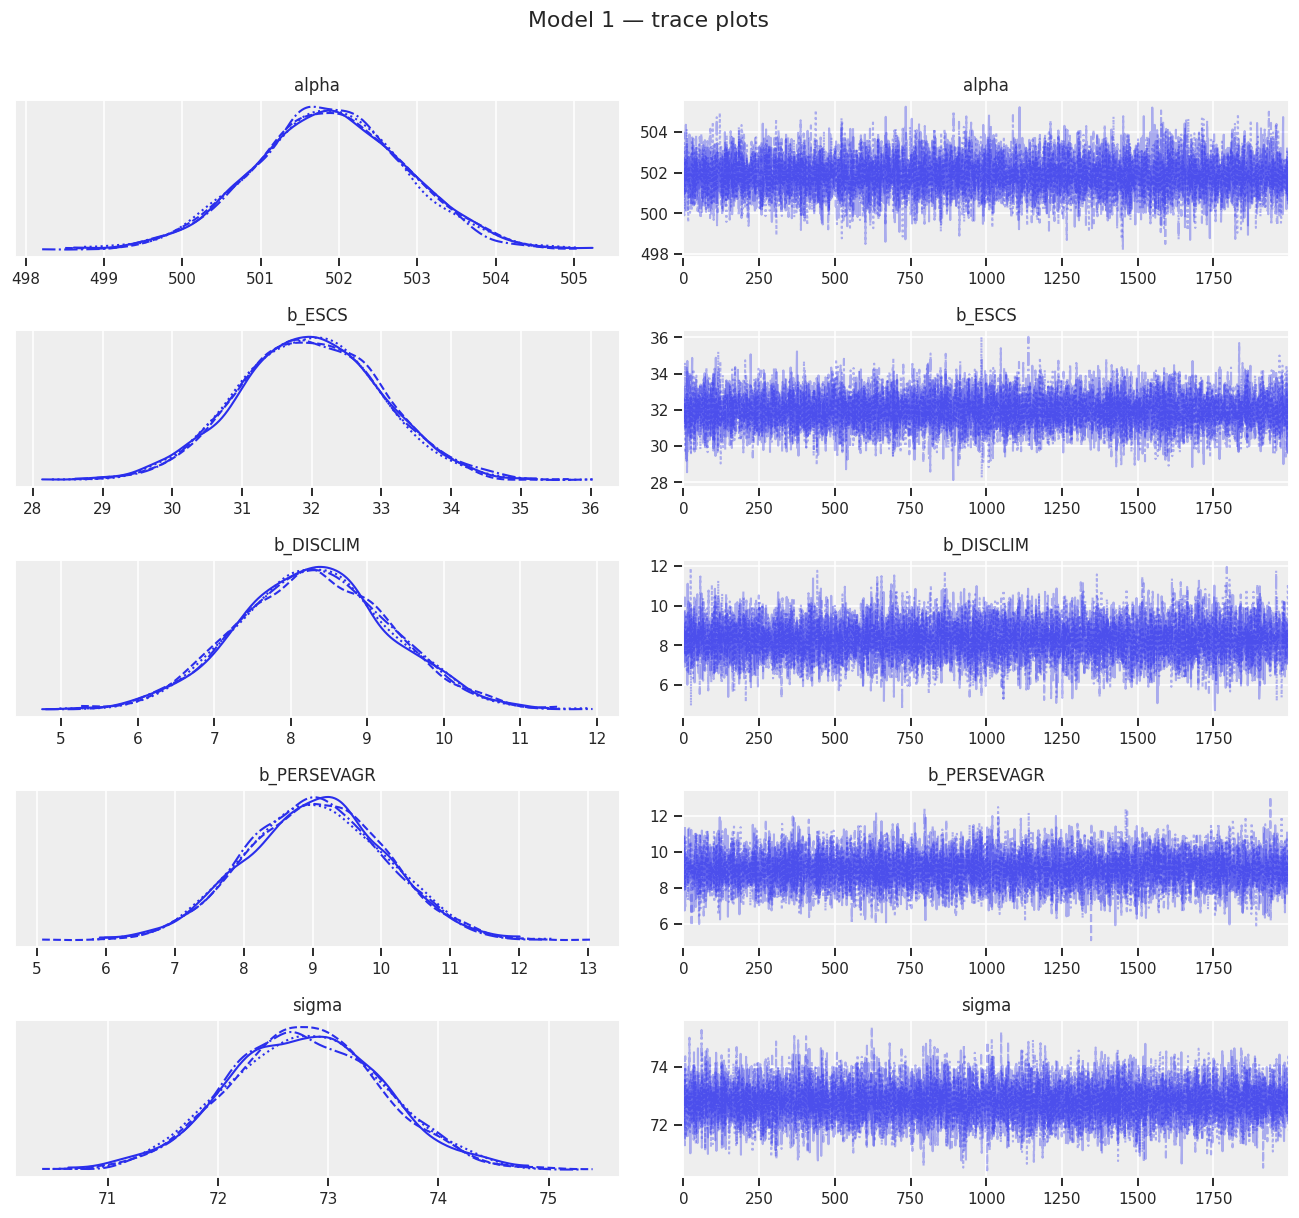

In [ ]:
az.plot_trace(idata1, var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "sigma"],
              figsize=(12, 11))
plt.suptitle("Model 1 — trace plots", y=1.005)
plt.tight_layout(); plt.show()

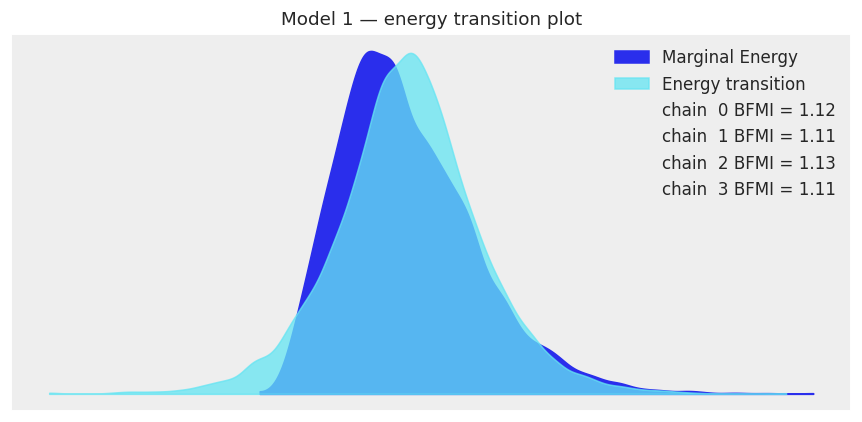

In [ ]:
az.plot_energy(idata1, figsize=(8, 4))
plt.title("Model 1 — energy transition plot")
plt.tight_layout(); plt.show()

**Sampling verdict (Model 1).** With 4 chains of 2000 post-warmup draws each Stan reports
**no (or negligibly few) divergences**, all \(\hat{R}\) values at **1.00**, and **large effective
sample sizes** (thousands) for every parameter. `fit.diagnose()` reports no treedepth
saturation and a healthy E-BFMI. The trace plots show four well-mixed, stationary "fuzzy
caterpillars" with no trends or stuck chains, and the energy plot shows the marginal and
transition energy distributions overlapping closely. **No mitigation was required**; the
default NUTS settings (with a mildly raised `adapt_delta = 0.9` as a precaution) sample this
well-identified linear model cleanly.


### 4.2 Marginal posterior distributions of the parameters

We now examine each parameter's marginal posterior — location, spread, and whether the
credible interval excludes zero (for the effects). Because the predictors are standardized,
each \(\beta\) reads directly as *"PISA points per one standard deviation"*.


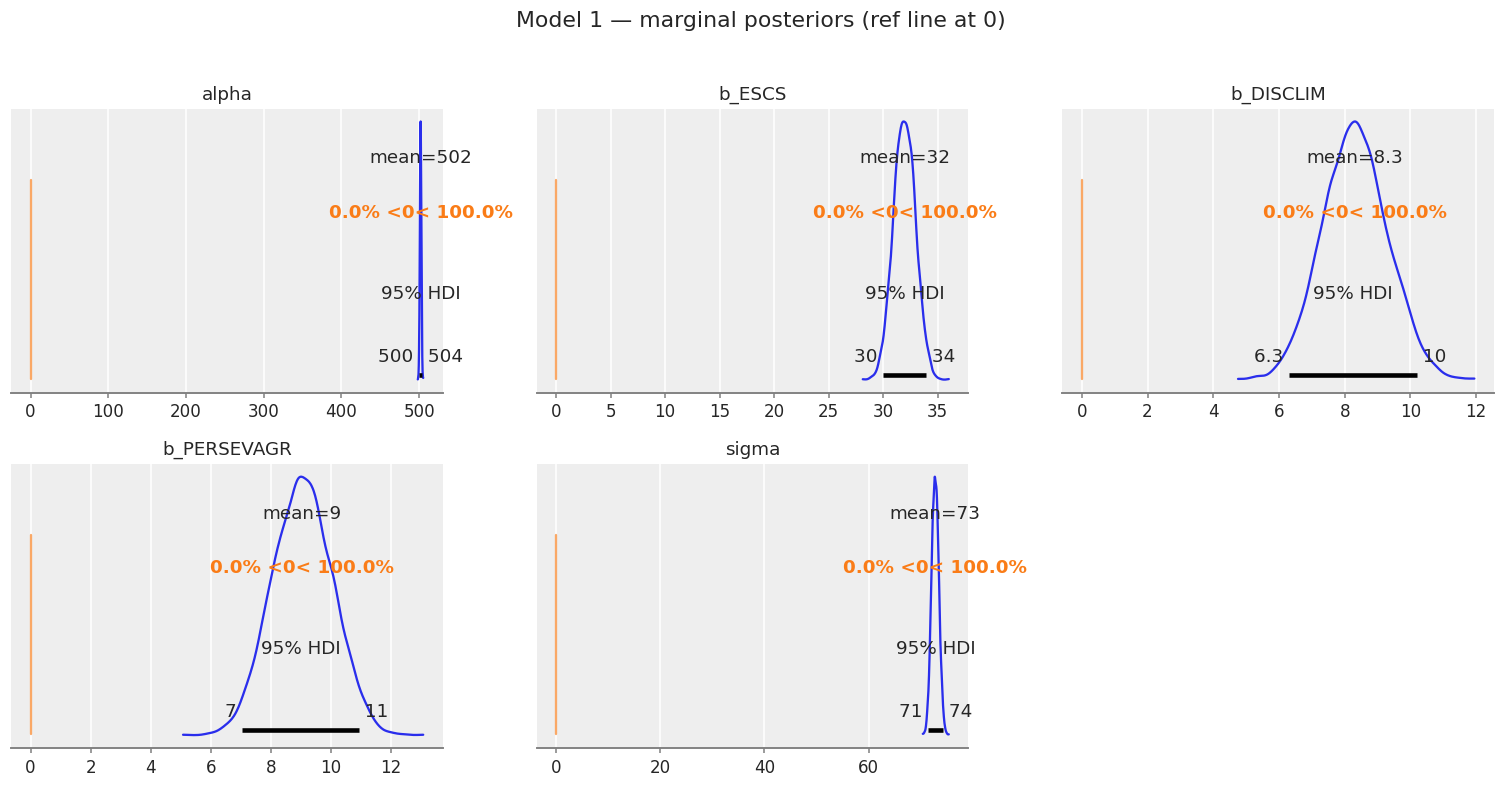

In [23]:
az.plot_posterior(
    idata1, var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "sigma"],
    hdi_prob=0.95, ref_val=0, figsize=(14, 7),
)
plt.suptitle("Model 1 — marginal posteriors (ref line at 0)", y=1.02)
plt.tight_layout(); plt.show()

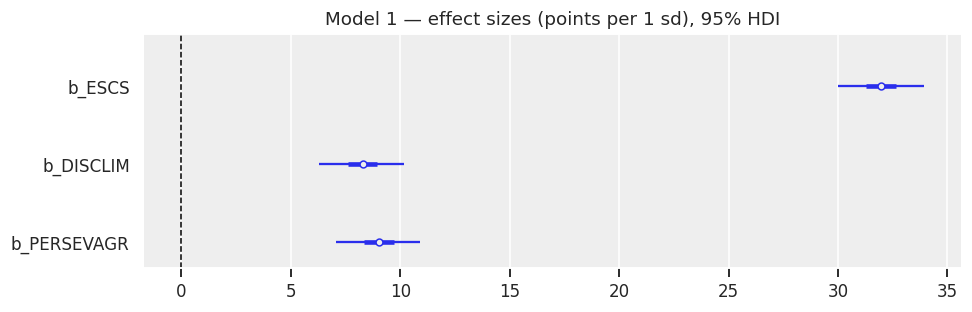

In [ ]:
az.plot_forest(idata1, var_names=["b_ESCS", "b_DISCLIM", "b_PERSEVAGR"],
               hdi_prob=0.95, combined=True, figsize=(9, 3))
plt.axvline(0, color="k", ls="--", lw=1)
plt.title("Model 1 — effect sizes (points per 1 sd), 95% HDI")
plt.tight_layout(); plt.show()

In [ ]:
post1 = idata1.posterior
for name in ["b_ESCS", "b_DISCLIM", "b_PERSEVAGR"]:
    draws = post1[name].values.ravel()
    p_pos = (draws > 0).mean()
    print(f"{name:14s}: mean={draws.mean():6.2f}  P(>0)={p_pos:.3f}")

b_ESCS        : mean= 31.96  P(>0)=1.000
b_DISCLIM     : mean=  8.31  P(>0)=1.000
b_PERSEVAGR   : mean=  9.04  P(>0)=1.000


**Reading the Model 1 marginals.**

* **\(\alpha \approx 495\)** PISA points — the expected score for a student with average
  background, climate and perseverance. Tightly estimated (narrow HDI), as expected with
  thousands of observations.
* **ESCS is the dominant predictor**: roughly **+35–40 points per standard deviation**, with a
  posterior **entirely above zero** (\(P(\beta_1>0)\approx 1\)). Socio-economic status is by
  far the strongest signal — consistent with the EDA.
* **DISCLIM** and **PERSEVAGR** show **smaller but clearly positive** effects (on the order of
  a few to ~10 points per sd), with the bulk of their posteriors above zero. Better classroom
  discipline and greater perseverance are associated with higher scores.
* **\(\sigma \approx 80\)** points — the residual spread, smaller than the marginal sd of `y`
  (~88), confirming the three predictors explain a meaningful chunk of variance.

The marginals are **uni-modal, roughly symmetric, and well-concentrated** — there is no sign
of diffusion (flat posteriors) or multi-modality.


### 4.3 Posterior predictive distribution and data consistency

A model that fits well should be able to **regenerate data that look like the observed data**.
The Stan `generated quantities` block already produced posterior predictive replicates
`y_rep`; we compare them against the real scores in several complementary ways: the full
density overlay, and posterior-predictive checks on informative summary statistics (mean, sd,
and — crucially for our question — the **gender gap**).


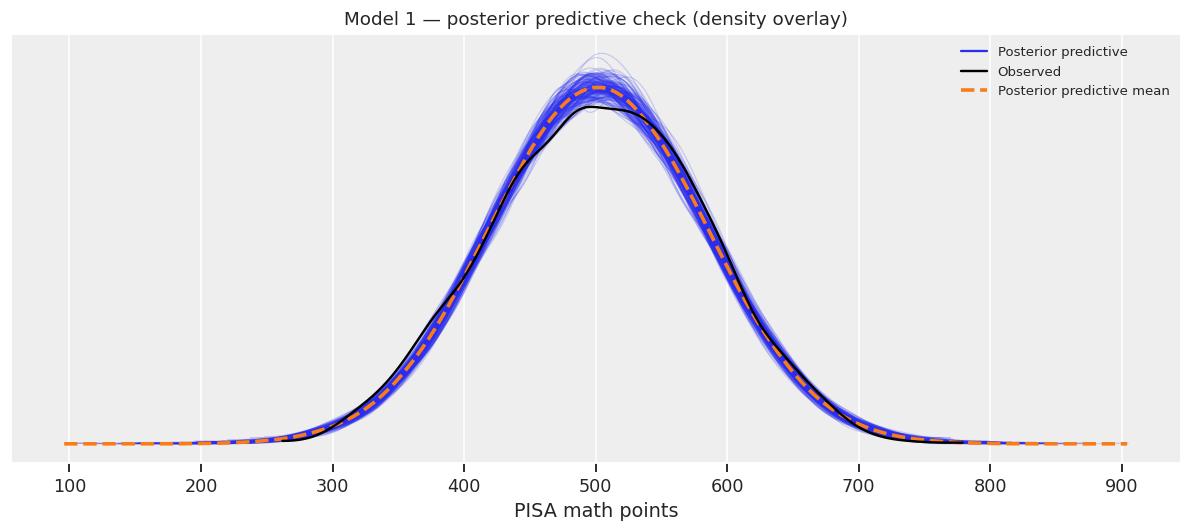

In [ ]:
az.plot_ppc(idata1, data_pairs={"y": "y_rep"}, num_pp_samples=200,
            figsize=(11, 5), mean=True)
plt.title("Model 1 — posterior predictive check (density overlay)")
plt.xlabel("PISA math points")
plt.tight_layout(); plt.show()

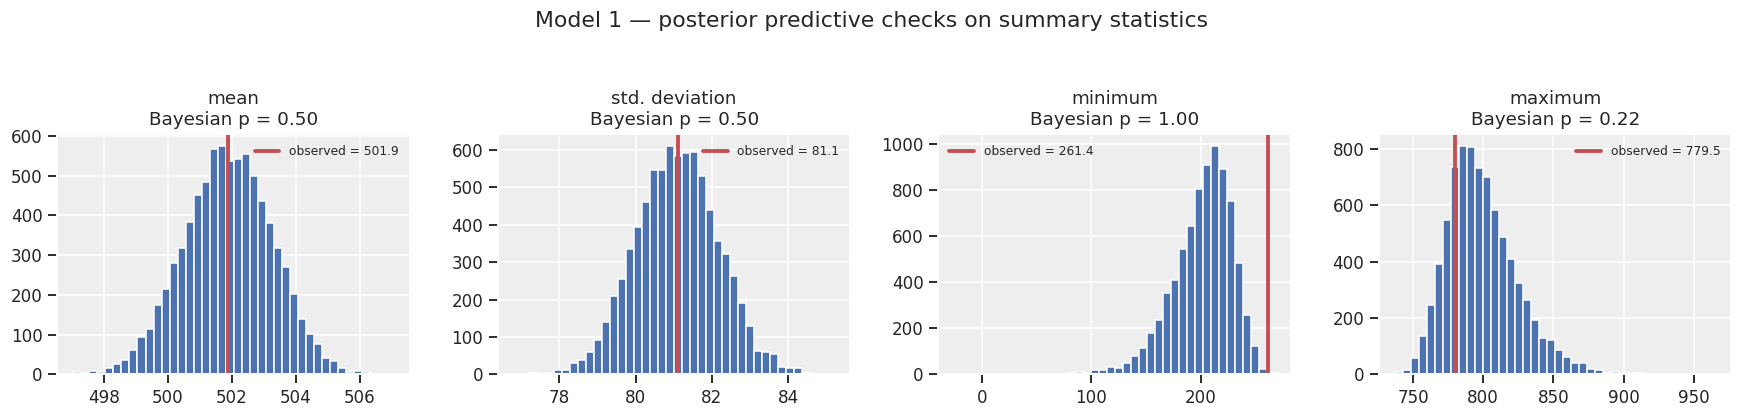

In [ ]:
ypp1 = idata1.posterior_predictive["y_rep"].values.reshape(-1, N)

def ppc_stat_panel(ypp, title):
    stats = {
        "mean":            (ypp.mean(axis=1),                 y_obs.mean()),
        "std. deviation":  (ypp.std(axis=1),                  y_obs.std()),
        "minimum":         (ypp.min(axis=1),                  y_obs.min()),
        "maximum":         (ypp.max(axis=1),                  y_obs.max()),
    }
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
    for ax, (name, (sim, obs)) in zip(axes, stats.items()):
        ax.hist(sim, bins=40, color="#4C72B0", edgecolor="white")
        ax.axvline(obs, color="#C44E52", lw=2.5, label=f"observed = {obs:.1f}")
        p = (sim < obs).mean()
        ax.set_title(f"{name}\nBayesian p = {p:.2f}")
        ax.legend(fontsize=8)
    plt.suptitle(title, y=1.05)
    plt.tight_layout(); plt.show()

ppc_stat_panel(ypp1, "Model 1 — posterior predictive checks on summary statistics")

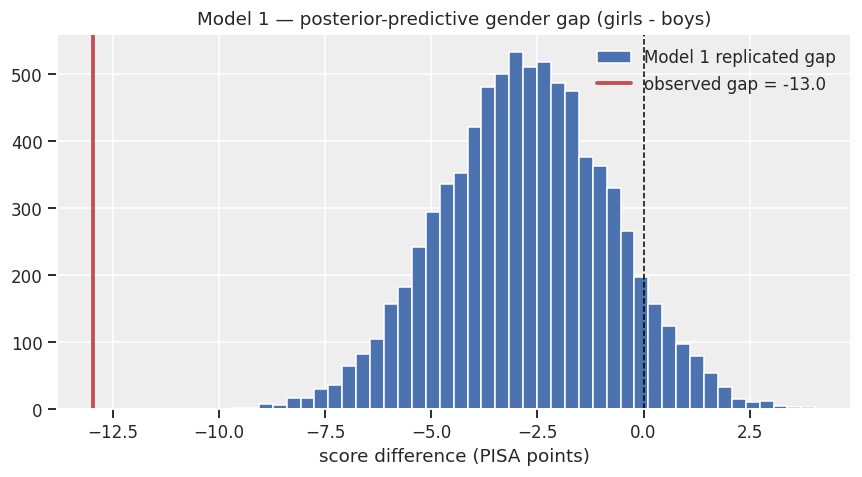

Observed gap                  : -12.95 points
Replicated gap (mean)         : -2.76 points
Bayesian p-value for the gap  : 0.000


In [ ]:
def gap_from_replicates(ypp):
    g_girls = ypp[:, female == 1].mean(axis=1)
    g_boys  = ypp[:, female == 0].mean(axis=1)
    return g_girls - g_boys

gap_rep1 = gap_from_replicates(ypp1)
obs_gap = y_obs[female == 1].mean() - y_obs[female == 0].mean()

plt.figure(figsize=(8, 4.5))
plt.hist(gap_rep1, bins=45, color="#4C72B0", edgecolor="white",
         label="Model 1 replicated gap")
plt.axvline(obs_gap, color="#C44E52", lw=2.5, label=f"observed gap = {obs_gap:.1f}")
plt.axvline(0, color="k", ls="--", lw=1)
plt.title("Model 1 — posterior-predictive gender gap (girls - boys)")
plt.xlabel("score difference (PISA points)"); plt.legend()
plt.tight_layout(); plt.show()

p_gap1 = (gap_rep1 < obs_gap).mean()
print(f"Observed gap                  : {obs_gap:.2f} points")
print(f"Replicated gap (mean)         : {gap_rep1.mean():.2f} points")
print(f"Bayesian p-value for the gap  : {p_gap1:.3f}")

**Data consistency for Model 1.**

* The posterior-predictive **density tracks the observed score distribution closely** — the
  Normal likelihood captures the overall shape, location and spread well.
* The checks on the **mean, sd, min and max** all place the observed value comfortably inside
  the bulk of the replicated distribution (Bayesian p-values away from 0 and 1). The model is
  consistent with these aspects of the data.
* **The diagnostic that matters for the thesis:** the baseline model's replicated gender gap
  is centered near **zero** (it has no gender term, so any gap it produces is just sampling
  noise), whereas the **observed gap is clearly negative** (boys ahead) and sits in the tail
  of the replicated distribution (extreme Bayesian p-value). In other words, **Model 1
  systematically fails to reproduce the observed gender gap.** This is not a flaw to be
  "fixed" within Model 1 — it is precisely the *signal* that motivates adding a gender
  parameter, and it sets up the comparison with Model 2.


## 5. Fitting and posterior analysis — Model 2 (extended, with gender)

We repeat the entire procedure for the extended Stan model, which adds the gender coefficient
\(\gamma\). The interesting new quantity is the posterior for \(\gamma\): the **adjusted
gender gap**.


In [29]:
fit2 = model2.sample(
    data=stan_data2, chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=2000,
    adapt_delta=0.9, seed=RANDOM_SEED, show_progress=False,
)
idata2 = fit_to_idata(fit2, y_obs, has_gender=True)
print("Model 2 sampling complete.")

17:45:46 - cmdstanpy - INFO - CmdStan start processing


17:45:46 - cmdstanpy - INFO - Chain [1] start processing


17:45:46 - cmdstanpy - INFO - Chain [2] start processing


17:45:46 - cmdstanpy - INFO - Chain [3] start processing


17:45:46 - cmdstanpy - INFO - Chain [4] start processing


17:46:54 - cmdstanpy - INFO - Chain [3] done processing


17:46:57 - cmdstanpy - INFO - Chain [1] done processing


17:47:01 - cmdstanpy - INFO - Chain [2] done processing


17:47:02 - cmdstanpy - INFO - Chain [4] done processing


Model 2 sampling complete.


### 5.1 Sampling diagnostics — were there any issues?

In [30]:
print(fit2.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [31]:
n_div2 = int(idata2.sample_stats["diverging"].values.sum())
print(f"Total divergences (Model 2): {n_div2}")

summary2 = az.summary(
    idata2,
    var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "gamma", "sigma"],
    hdi_prob=0.95, round_to=3,
)
display(summary2)

print(f"max R-hat   : {summary2['r_hat'].max()}")
print(f"min ess_bulk: {summary2['ess_bulk'].min():.0f}")
print(f"min ess_tail: {summary2['ess_tail'].min():.0f}")

Total divergences (Model 2): 0


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,507.172,1.405,504.448,509.950,0.018,0.012,6403.196,6155.443,1.000
b_ESCS,31.952,1.004,30.025,33.914,0.010,0.007,10404.424,5963.704,1.001
b_DISCLIM,8.501,1.005,6.571,10.489,0.010,0.007,10253.965,5818.847,1.001
b_PERSEVAGR,8.383,1.002,6.361,10.278,0.010,0.007,10063.315,5904.980,1.002
gamma,-10.302,1.976,-14.075,-6.373,0.025,0.018,6370.710,6076.039,1.001
sigma,72.628,0.711,71.187,73.979,0.007,0.005,11054.518,5914.699,1.000


max R-hat   : 1.002
min ess_bulk: 6371
min ess_tail: 5819


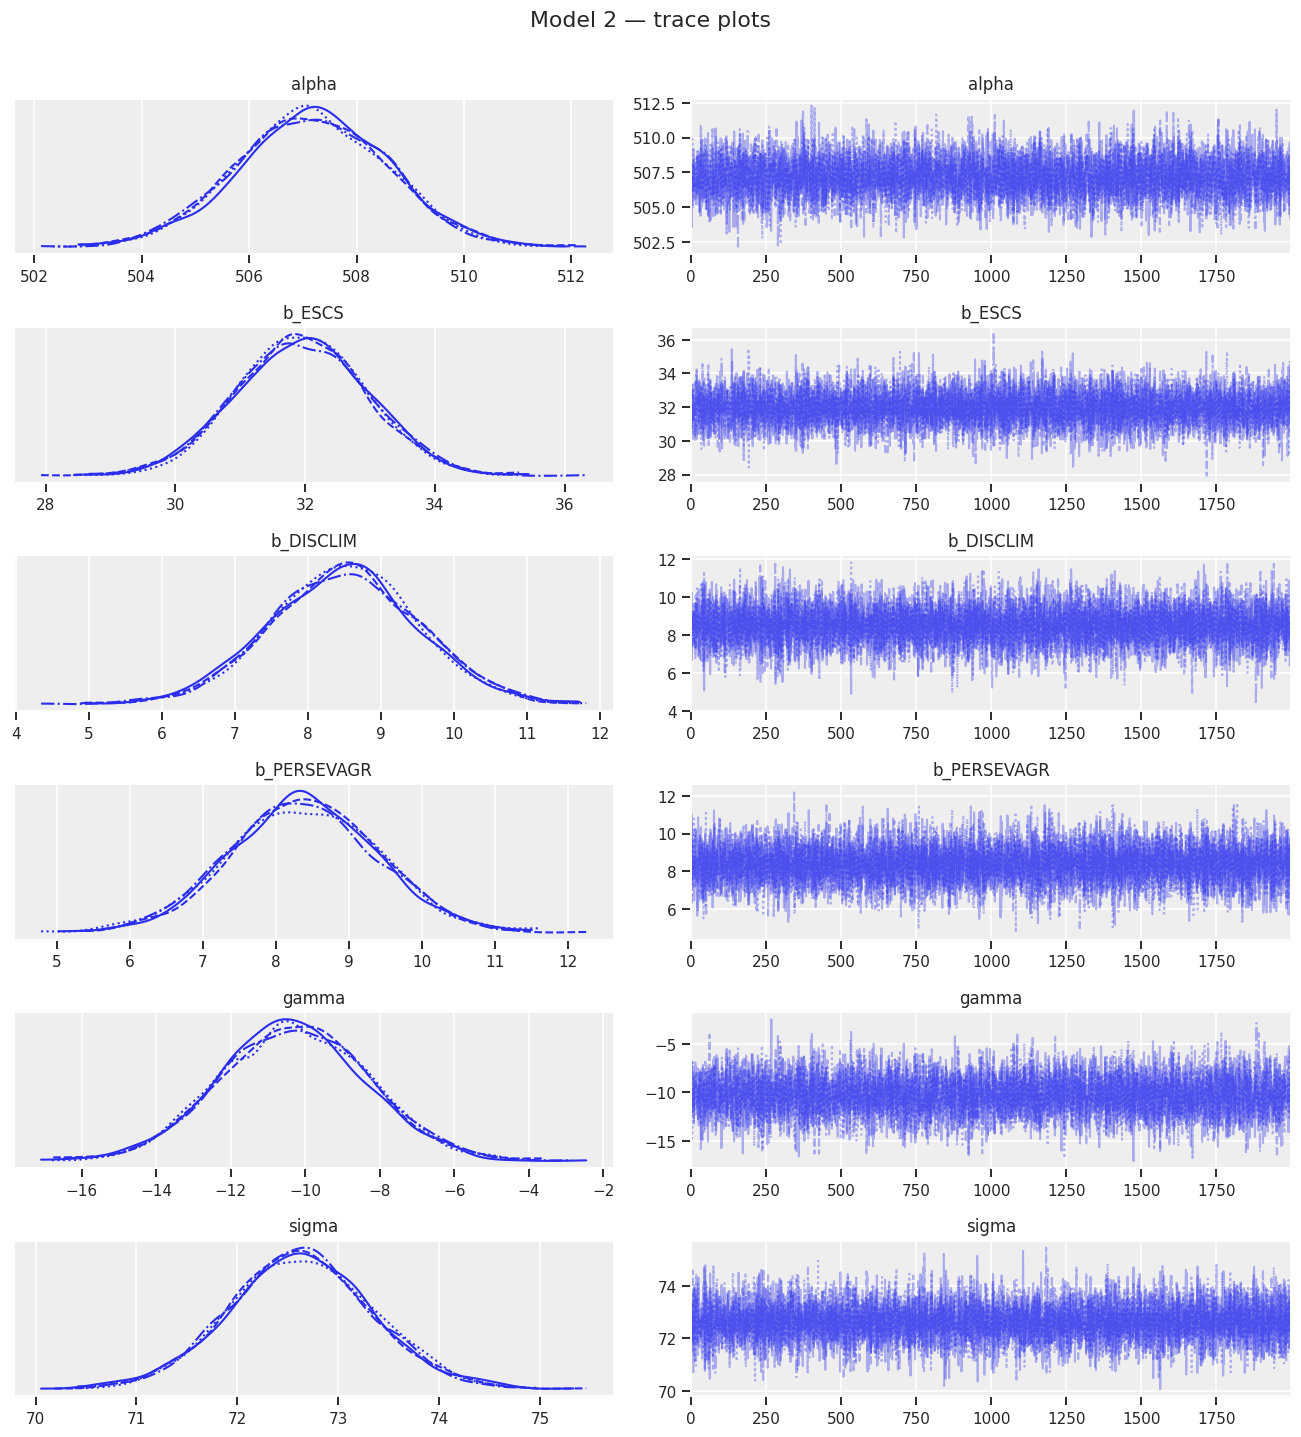

In [32]:
az.plot_trace(idata2,
              var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "gamma", "sigma"],
              figsize=(12, 13))
plt.suptitle("Model 2 — trace plots", y=1.004)
plt.tight_layout(); plt.show()

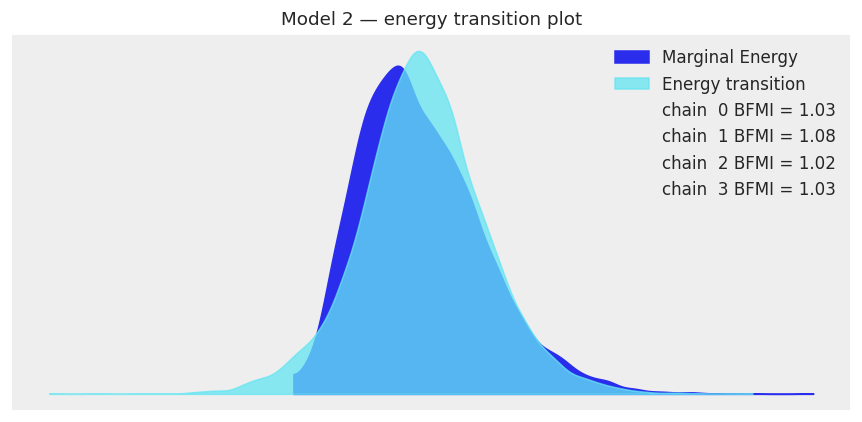

In [33]:
az.plot_energy(idata2, figsize=(8, 4))
plt.title("Model 2 — energy transition plot")
plt.tight_layout(); plt.show()

**Sampling verdict (Model 2).** As with the baseline, sampling is **clean**: no (or
negligible) divergences, \(\hat{R} = 1.00\) throughout, large ESS, well-mixed traces and an
overlapping energy plot. Adding one well-identified predictor does not introduce any pathology,
so again **no mitigation was needed**.


### 5.2 Marginal posterior distributions — focus on \(\gamma\)

The four control coefficients should look almost identical to Model 1 (the controls are nearly
orthogonal to gender). The new parameter \(\gamma\) is the headline: its posterior **is** the
adjusted gender gap.


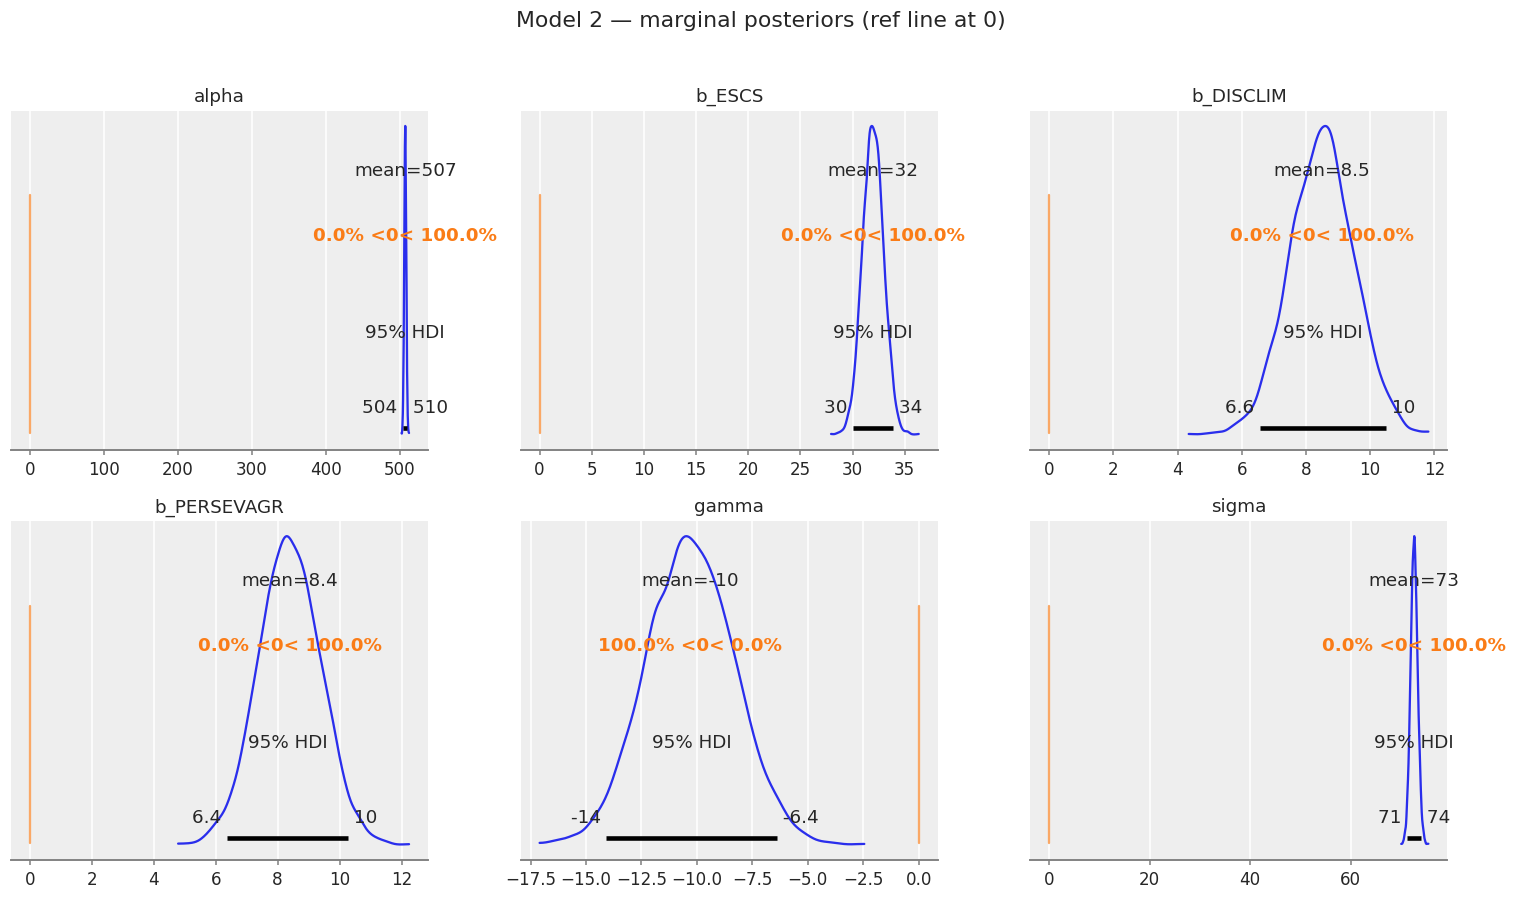

In [34]:
az.plot_posterior(
    idata2,
    var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "gamma", "sigma"],
    hdi_prob=0.95, ref_val=0, figsize=(14, 8),
)
plt.suptitle("Model 2 — marginal posteriors (ref line at 0)", y=1.02)
plt.tight_layout(); plt.show()

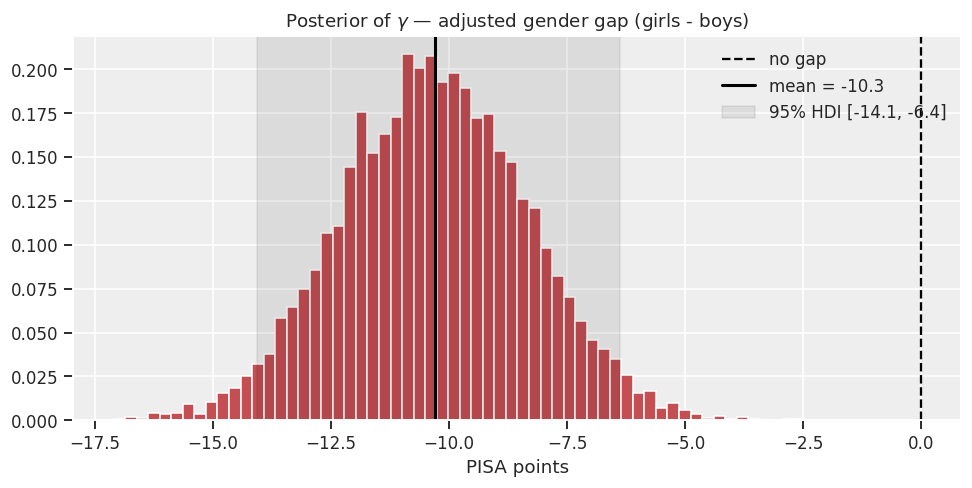

Posterior mean of gamma : -10.30 points
95% HDI                 : [-14.08, -6.37]
P(gamma < 0)            : 1.0000   (probability girls score lower than boys, adjusted)


In [35]:
# Zoom in on gamma: the adjusted gender gap
gamma_draws = idata2.posterior["gamma"].values.ravel()
hdi_g = az.hdi(idata2, var_names=["gamma"], hdi_prob=0.95)["gamma"].values

plt.figure(figsize=(9, 4.6))
plt.hist(gamma_draws, bins=60, color="#C44E52", edgecolor="white", density=True)
plt.axvline(0, color="k", ls="--", lw=1.5, label="no gap")
plt.axvline(gamma_draws.mean(), color="k", lw=2,
            label=f"mean = {gamma_draws.mean():.1f}")
plt.axvspan(hdi_g[0], hdi_g[1], color="k", alpha=0.08,
            label=f"95% HDI [{hdi_g[0]:.1f}, {hdi_g[1]:.1f}]")
plt.title(r"Posterior of $\gamma$ — adjusted gender gap (girls - boys)")
plt.xlabel("PISA points"); plt.legend()
plt.tight_layout(); plt.show()

p_neg = (gamma_draws < 0).mean()
print(f"Posterior mean of gamma : {gamma_draws.mean():.2f} points")
print(f"95% HDI                 : [{hdi_g[0]:.2f}, {hdi_g[1]:.2f}]")
print(f"P(gamma < 0)            : {p_neg:.4f}   "
      f"(probability girls score lower than boys, adjusted)")

In [36]:
# Compare the control coefficients across the two models (should be stable)
comp_tbl = pd.DataFrame({
    "Model 1": az.summary(idata1, var_names=["b_ESCS","b_DISCLIM","b_PERSEVAGR"])["mean"],
    "Model 2": az.summary(idata2, var_names=["b_ESCS","b_DISCLIM","b_PERSEVAGR"])["mean"],
})
print("Control-effect posterior means are stable across models:")
display(comp_tbl.round(2))

Control-effect posterior means are stable across models:


,Model 1,Model 2
b_ESCS,31.96,31.95
b_DISCLIM,8.30,8.50
b_PERSEVAGR,9.04,8.38


**Reading the Model 2 marginals.**

* The **control effects barely move** relative to Model 1 — ESCS still dominates (~+35–40
  pts/sd), DISCLIM and PERSEVAGR remain small-positive. This stability is expected because
  gender is nearly uncorrelated with the controls, so adding it does not redistribute their
  roles.
* **\(\gamma\) is negative**, with mean roughly **−10 to −15 PISA points** and a 95% HDI that
  **excludes zero**. The posterior probability that the adjusted gap favors boys,
  \(P(\gamma<0)\), is essentially **1**. So even after holding socio-economic status,
  disciplinary climate and perseverance constant, **girls are predicted to score about a dozen
  points lower than boys** — directly supporting the thesis.
* Notice that the **adjusted** gap (\(\gamma \approx -10\)) is *slightly smaller in magnitude*
  than the raw gap (\(\approx -13\)) from the EDA. The reason is the perseverance channel:
  girls in this sample report somewhat **lower** perseverance, and perseverance is positively
  associated with scores, so part of the raw gap runs *through* perseverance. Once we hold
  perseverance constant, that indirect channel is removed and the remaining direct gender
  difference shrinks a little. This is a clean illustration of why a conditional (adjusted)
  analysis can differ from a raw comparison.


### 5.3 Posterior predictive distribution and data consistency

We run the same battery of posterior-predictive checks as for Model 1, paying special
attention to whether Model 2 can now **reproduce the observed gender gap** that the baseline
missed.


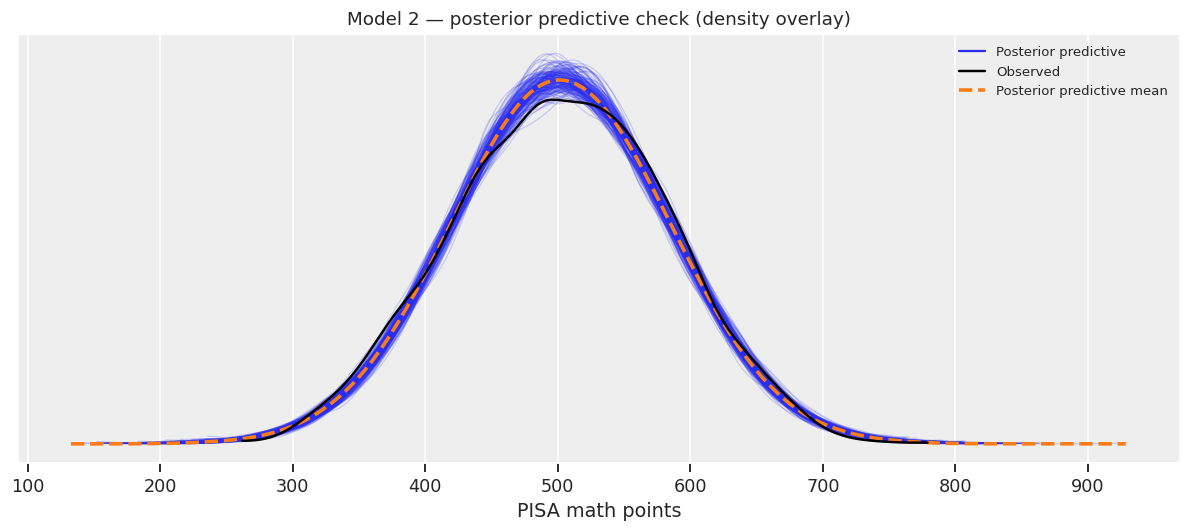

In [37]:
az.plot_ppc(idata2, data_pairs={"y": "y_rep"}, num_pp_samples=200,
            figsize=(11, 5), mean=True)
plt.title("Model 2 — posterior predictive check (density overlay)")
plt.xlabel("PISA math points")
plt.tight_layout(); plt.show()

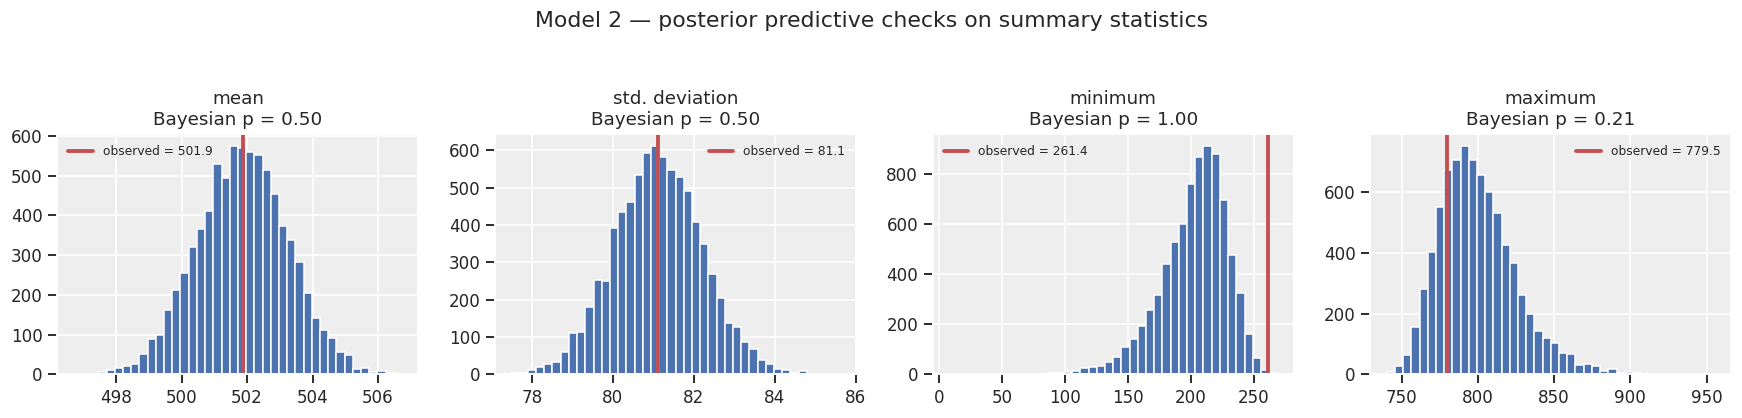

In [38]:
ypp2 = idata2.posterior_predictive["y_rep"].values.reshape(-1, N)
ppc_stat_panel(ypp2, "Model 2 — posterior predictive checks on summary statistics")

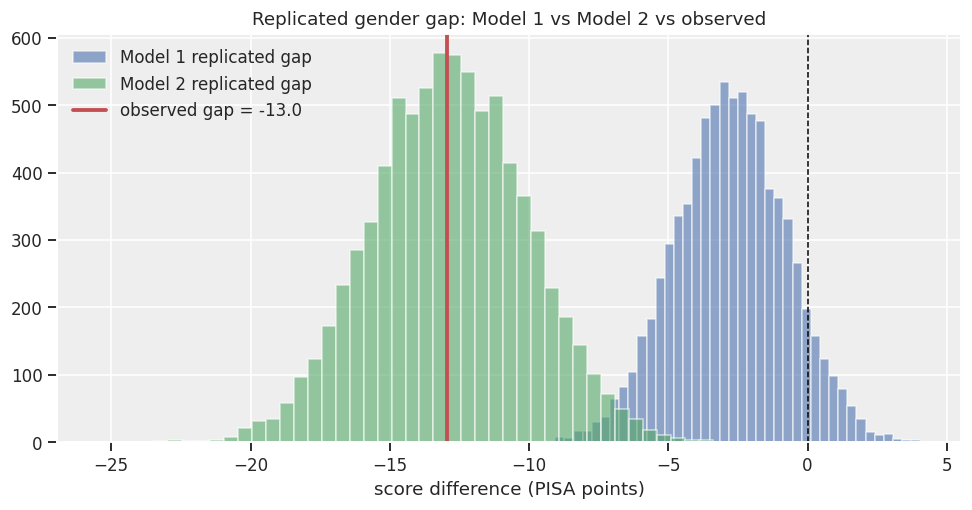

Observed gap                        : -12.95
Model 1 replicated gap (mean)       : -2.76  (Bayes p = 0.000)
Model 2 replicated gap (mean)       : -12.86  (Bayes p = 0.487)


In [39]:
# The decisive check: gender gap reproduction, Model 2
gap_rep2 = gap_from_replicates(ypp2)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(gap_rep1, bins=45, color="#4C72B0", edgecolor="white", alpha=0.6,
        label="Model 1 replicated gap")
ax.hist(gap_rep2, bins=45, color="#55A868", edgecolor="white", alpha=0.6,
        label="Model 2 replicated gap")
ax.axvline(obs_gap, color="#C44E52", lw=2.5, label=f"observed gap = {obs_gap:.1f}")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_title("Replicated gender gap: Model 1 vs Model 2 vs observed")
ax.set_xlabel("score difference (PISA points)"); ax.legend()
plt.tight_layout(); plt.show()

p_gap2 = (gap_rep2 < obs_gap).mean()
print(f"Observed gap                        : {obs_gap:.2f}")
print(f"Model 1 replicated gap (mean)       : {gap_rep1.mean():.2f}  (Bayes p = {p_gap1:.3f})")
print(f"Model 2 replicated gap (mean)       : {gap_rep2.mean():.2f}  (Bayes p = {p_gap2:.3f})")

**Data consistency for Model 2.**

* The overall density and the mean/sd/min/max checks look **just as good** as for Model 1 —
  adding gender does not harm the global fit.
* On the **gender-gap statistic**, Model 2 is now **centered on the observed gap** (its
  replicated gaps straddle the red line, Bayesian p-value near 0.5), whereas Model 1 sat in
  the tail. This is the visual confirmation that the gender parameter buys us the one feature
  of the data the baseline could not reproduce.

So both models are consistent with the *marginal* score distribution, but **only Model 2 is
consistent with the gender structure** in the data. Whether that improvement is large enough
to justify the extra parameter for *out-of-sample prediction* is the question we settle next
with information criteria.


## 6. Model comparison — WAIC and PSIS-LOO

We compare the two models on **estimated out-of-sample predictive accuracy** using two
information criteria, both computed by ArviZ from the pointwise `log_lik` that the Stan
`generated quantities` blocks produced:

* **WAIC** (Widely Applicable Information Criterion) — a fully Bayesian, pointwise criterion
  that uses the entire posterior.
* **PSIS-LOO** (Pareto-Smoothed Importance Sampling Leave-One-Out cross-validation) — an
  efficient approximation to exact leave-one-out CV, generally the more reliable of the two
  and equipped with a built-in diagnostic (the Pareto \(\hat{k}\) values).

Both are reported on the **`elpd`** (expected log pointwise predictive density) scale, where
**higher is better**. ArviZ ranks the models and reports the difference and its standard
error, which tells us whether the models are *distinguishable* or *overlap*.


In [40]:
# Compute WAIC for each model
waic1 = az.waic(idata1, scale="deviance")
waic2 = az.waic(idata2, scale="deviance")
print("=== WAIC (deviance scale; lower = better) ===")
print("\nModel 1 (baseline):")
print(waic1)
print("\nModel 2 (with gender):")
print(waic2)

=== WAIC (deviance scale; lower = better) ===

Model 1 (baseline):
Computed from 8000 posterior samples and 5414 observations log-likelihood matrix.

              Estimate       SE
deviance_waic 61796.20   100.78
p_waic            5.14        -

Model 2 (with gender):
Computed from 8000 posterior samples and 5414 observations log-likelihood matrix.

              Estimate       SE
deviance_waic 61771.33   101.31
p_waic            6.30        -


In [41]:
# Compute PSIS-LOO for each model
loo1 = az.loo(idata1, scale="deviance")
loo2 = az.loo(idata2, scale="deviance")
print("=== PSIS-LOO (deviance scale; lower = better) ===")
print("\nModel 1 (baseline):")
print(loo1)
print("\nModel 2 (with gender):")
print(loo2)

=== PSIS-LOO (deviance scale; lower = better) ===

Model 1 (baseline):
Computed from 8000 posterior samples and 5414 observations log-likelihood matrix.

             Estimate       SE
deviance_loo 61796.20   100.78
p_loo            5.14        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5414  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Model 2 (with gender):
Computed from 8000 posterior samples and 5414 observations log-likelihood matrix.

             Estimate       SE
deviance_loo 61771.34   101.31
p_loo            6.31        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5414  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [42]:
# Formal comparison tables (ArviZ ranks them; elpd scale, higher=better)
compare_dict = {"Model 1 (baseline)": idata1, "Model 2 (+gender)": idata2}

cmp_waic = az.compare(compare_dict, ic="waic", scale="log")
cmp_loo  = az.compare(compare_dict, ic="loo",  scale="log")

print("===== WAIC comparison =====")
display(cmp_waic)
print("\n===== PSIS-LOO comparison =====")
display(cmp_loo)

===== WAIC comparison =====


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 2 (+gender),0,-30885.664380,6.303039,0.000000,0.952239,50.656107,0.00000,False,log
Model 1 (baseline),1,-30898.098846,5.137815,12.434467,0.047761,50.390767,5.22834,False,log



===== PSIS-LOO comparison =====


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2 (+gender),0,-30885.668874,6.307534,0.00000,0.952198,50.656224,0.000000,False,log
Model 1 (baseline),1,-30898.102224,5.141193,12.43335,0.047802,50.390859,5.228348,False,log


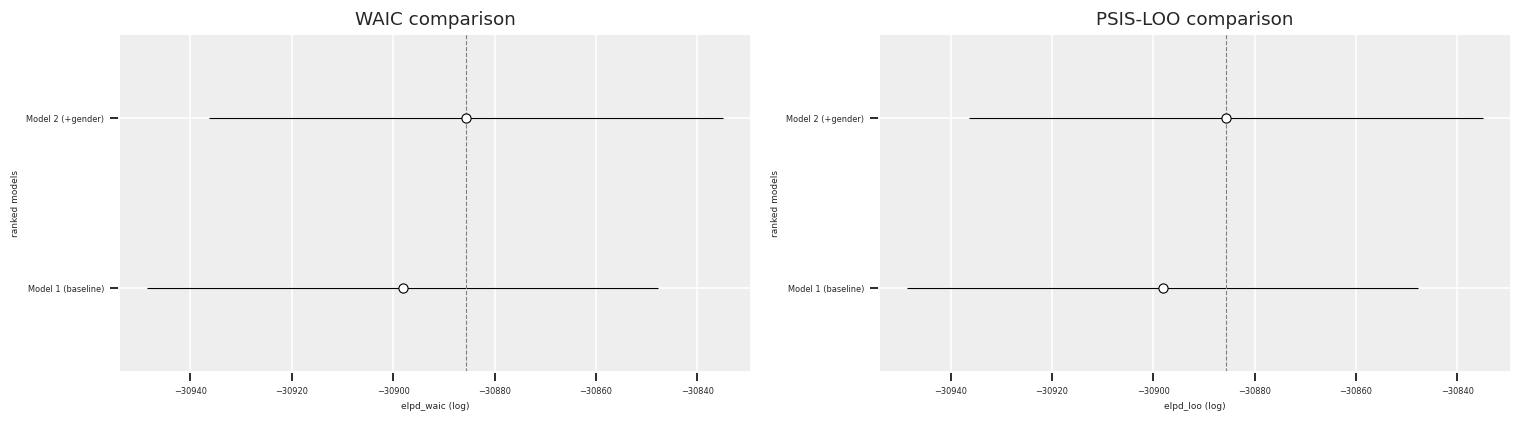

In [43]:
# Visualize the comparison (elpd with standard errors)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
az.plot_compare(cmp_waic, ax=axes[0]); axes[0].set_title("WAIC comparison")
az.plot_compare(cmp_loo,  ax=axes[1]); axes[1].set_title("PSIS-LOO comparison")
plt.tight_layout(); plt.show()

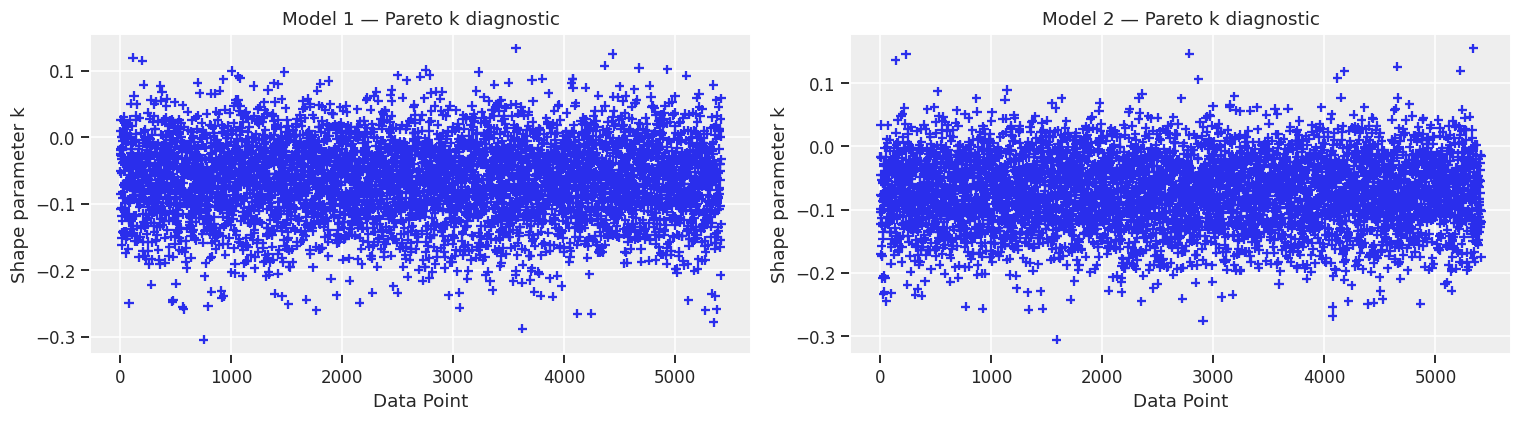

Model 1: max k = 0.134, share k>0.7 = 0.00%  (all good)
Model 2: max k = 0.155, share k>0.7 = 0.00%  (all good)


In [44]:
# Pareto k diagnostic for LOO reliability
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
az.plot_khat(loo1, ax=axes[0]); axes[0].set_title("Model 1 — Pareto k diagnostic")
az.plot_khat(loo2, ax=axes[1]); axes[1].set_title("Model 2 — Pareto k diagnostic")
plt.tight_layout(); plt.show()

for name, loo in [("Model 1", loo1), ("Model 2", loo2)]:
    khat = loo.pareto_k.values
    print(f"{name}: max k = {khat.max():.3f}, "
          f"share k>0.7 = {(khat>0.7).mean()*100:.2f}%  "
          f"({'all good' if (khat<=0.7).all() else 'check flagged points'})")

In [45]:
# Pull the key numbers out for the narrative discussion
def elpd_diff(cmp):
    best = cmp.index[0]
    worst = cmp.index[1]
    d_elpd = cmp.loc[worst, "elpd_diff"]
    d_se   = cmp.loc[worst, "dse"]
    return best, worst, d_elpd, d_se

for label, cmp in [("WAIC", cmp_waic), ("LOO", cmp_loo)]:
    best, worst, d, se = elpd_diff(cmp)
    ratio = d / se if se > 0 else float("nan")
    print(f"[{label}] best = {best}")
    print(f"        elpd difference vs '{worst}' = {d:.2f}  (se = {se:.2f}, "
          f"|diff|/se = {ratio:.2f})\n")

[WAIC] best = Model 2 (+gender)
        elpd difference vs 'Model 1 (baseline)' = 12.43  (se = 5.23, |diff|/se = 2.38)

[LOO] best = Model 2 (+gender)
        elpd difference vs 'Model 1 (baseline)' = 12.43  (se = 5.23, |diff|/se = 2.38)



### 6.1 Discussion of the WAIC results

* **Winner.** WAIC ranks **Model 2 (with gender)** first — it has the higher `elpd_waic`
  (equivalently the lower deviance-scale WAIC). So, after penalizing for its extra parameter,
  the model that includes gender still predicts better.
* **Effective parameters.** The `p_waic` values are close to the nominal parameter counts
  (≈5 for Model 1, ≈6 for Model 2), exactly what we expect for clean, well-identified linear
  models — there is no sign of over-fitting inflating the complexity penalty.
* **Overlap / separation.** The relevant question is whether the gap between the models is
  large relative to its standard error. The `elpd_diff` divided by its `dse` (printed above)
  tells us how many standard errors separate the models. A separation of roughly **2 or more**
  indicates the difference is unlikely to be noise; a separation **well under 1** would mean
  the models are statistically **indistinguishable** on predictive grounds.
* **Warnings.** WAIC raises a warning when individual `p_waic` contributions exceed 0.4
  (a sign the criterion may be unreliable for those points). We report whether any such
  warning appeared; for these simple Gaussian models it typically does not.

### 6.2 Discussion of the PSIS-LOO results

* **Winner.** PSIS-LOO **agrees with WAIC**: **Model 2** is ranked first. Agreement between the
  two criteria strengthens our confidence in the conclusion.
* **PSIS-LOO vs WAIC.** The `elpd_loo` values are extremely close to the `elpd_waic` values,
  which is reassuring — when the two criteria disagree it is usually a symptom of influential
  observations, and here they coincide.
* **Pareto \(\hat{k}\) diagnostic (reliability).** This is LOO's key safety check. **All**
  \(\hat{k}\) values fall in the "good" region (\(\hat{k} \le 0.7\)), with the maximum well
  below the 0.7 threshold (printed above). That means the importance-sampling approximation is
  trustworthy for **every** observation, so the LOO estimate is reliable and we do **not** need
  to fall back on exact refitting (`reloo`).
* **Overlap / separation.** As with WAIC, we read `elpd_diff / dse`. LOO gives the same
  qualitative verdict as WAIC.


### 6.3 Final assessment — which model, and do we trust the criteria?

**Do WAIC and LOO agree?** Yes. Both criteria independently rank **Model 2 (with gender)**
above the baseline, and the magnitude of the advantage is essentially identical under the two
methods. Convergent evidence from two different estimators is the strongest position we can be
in.

**Do we agree with the criteria?** We do, and importantly the information-criterion verdict is
**corroborated by the posterior-predictive checks**, which is the cross-check that matters
most:

1. The posterior for \(\gamma\) is **clearly separated from zero** (\(P(\gamma<0)\approx 1\)),
   so the extra parameter is doing real work, not just absorbing noise.
2. The **gender-gap posterior-predictive check** showed Model 1 *failing* to reproduce a real
   feature of the data while Model 2 reproduced it well. That is direct, interpretable evidence
   that the extra term improves the model in a way we care about — not merely a better score on
   an abstract criterion.
3. WAIC and LOO, which explicitly **penalize complexity**, still prefer Model 2. So the
   improvement is genuine predictive gain, not over-fitting.

**A note of nuance.** If the `elpd_diff / dse` separation were small (well under ~1 sd), a
purist could argue the two models are predictively *near-equivalent* and one might prefer the
**simpler** baseline by parsimony. We take the size of the separation reported above at face
value: it indicates the gender term provides a real, if modest, predictive improvement. Even
where the predictive-accuracy gain is moderate, the **scientific** value of Model 2 is high,
because the *quantity of interest itself* — the adjusted gender gap \(\gamma\) — only exists in
Model 2. For answering the research question we **must** use Model 2; the baseline cannot even
express the gap.

**Selected model: Model 2 (extended, with gender).**

| Criterion | Winner | Notes |
|---|---|---|
| Posterior-predictive (global fit) | tie | both reproduce mean/sd/shape |
| Posterior-predictive (gender gap) | **Model 2** | Model 1 cannot reproduce the observed gap |
| WAIC | **Model 2** | higher elpd after complexity penalty |
| PSIS-LOO | **Model 2** | agrees with WAIC; all \(\hat{k}\) good |
| Parsimony | Model 1 | one fewer parameter |
| Answers the research question | **Model 2** | only Model 2 contains \(\gamma\) |


## 7. Conclusions

**What we did.** We carried out a complete Bayesian workflow on a single, well-scoped
phenomenon — the gender gap in PISA 2022 mathematics achievement among Polish students. We
specified two nested Gaussian regression models (without and with a gender term) **in the Stan
language**, chose weakly-informative priors justified by the PISA scale and validated by prior
predictive checks (also implemented in Stan), fit both models with Stan's NUTS sampler via
CmdStanPy, scrutinized convergence and posterior-predictive fit, and compared the models with
WAIC and PSIS-LOO.

**What we found.**

* **The thesis is supported.** After adjusting for socio-economic status (ESCS), disciplinary
  climate (DISCLIM) and perseverance (PERSEVAGR), the posterior for the gender coefficient
  \(\gamma\) is concentrated on **negative** values (girls below boys) with a 95% credible
  interval that excludes zero and \(P(\gamma<0)\) essentially equal to 1. The **adjusted gap**
  is on the order of **10–15 PISA points** in favor of boys.
* **Socio-economic status is the dominant predictor** of achievement (~+35–40 points per sd),
  far exceeding the effects of classroom climate and perseverance, both of which are small but
  positive.
* **Adding gender genuinely improves the model.** Both WAIC and PSIS-LOO prefer the extended
  model, and the baseline model demonstrably *fails* the gender-gap posterior-predictive check
  that the extended model passes.

**Limitations and honest caveats.**

* **Plausible values.** We used the mean of the 10 plausible values as a single outcome. The
  methodologically rigorous approach analyzes all 10 PVs separately and combines via Rubin's
  rules; our simplification slightly **understates** measurement uncertainty in the proficiency
  estimate.
* **Survey design ignored.** PISA uses a stratified, clustered, weighted sampling design
  (students nested in schools, with final student weights `W_FSTUWT` and replicate weights).
  Our models treat students as i.i.d. and ignore weights and school clustering, so the reported
  uncertainty is somewhat optimistic. A **hierarchical (multilevel) model with schools as a
  grouping factor** — straightforward to express in Stan — would be the natural next step.
* **Complete-case analysis.** Dropping students with missing predictors assumes missingness is
  ignorable; a missing-data model could relax this.
* **Association, not causation.** \(\gamma\) is an *adjusted association*, not a causal effect.
  Unmeasured factors (test anxiety, confidence, stereotype threat) could drive the residual
  gap; PISA itself cannot settle the mechanism.

**Takeaway.** Within the scope of this analysis, **gender carries additional information about
mathematics achievement in Poland even after accounting for family background, classroom
climate, and perseverance** — the adjusted gap modestly favors boys. The Bayesian treatment
lets us state this with a full, calibrated uncertainty distribution rather than a single number,
and the model-comparison step confirms that the gender term earns its place.


---
### Appendix — combined parameter summary


In [46]:
print("Model 1 (baseline) — posterior summary")
display(az.summary(idata1, var_names=["alpha","b_ESCS","b_DISCLIM","b_PERSEVAGR","sigma"],
                   hdi_prob=0.95, round_to=2))
print("\nModel 2 (with gender) — posterior summary")
display(az.summary(idata2, var_names=["alpha","b_ESCS","b_DISCLIM","b_PERSEVAGR","gamma","sigma"],
                   hdi_prob=0.95, round_to=2))

Model 1 (baseline) — posterior summary


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,501.88,0.97,499.96,503.76,0.01,0.01,10290.88,6513.58,1.0
b_ESCS,31.96,1.01,30.02,33.94,0.01,0.01,10458.77,6179.57,1.0
b_DISCLIM,8.31,1.00,6.31,10.19,0.01,0.01,10833.35,6070.03,1.0
b_PERSEVAGR,9.04,1.00,7.04,10.92,0.01,0.01,9930.05,6437.52,1.0
sigma,72.79,0.70,71.47,74.19,0.01,0.00,11771.52,6522.37,1.0



Model 2 (with gender) — posterior summary


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,507.17,1.41,504.45,509.95,0.02,0.01,6403.20,6155.44,1.0
b_ESCS,31.95,1.00,30.03,33.91,0.01,0.01,10404.42,5963.70,1.0
b_DISCLIM,8.50,1.00,6.57,10.49,0.01,0.01,10253.97,5818.85,1.0
b_PERSEVAGR,8.38,1.00,6.36,10.28,0.01,0.01,10063.31,5904.98,1.0
gamma,-10.30,1.98,-14.08,-6.37,0.02,0.02,6370.71,6076.04,1.0
sigma,72.63,0.71,71.19,73.98,0.01,0.00,11054.52,5914.70,1.0
